# Deep Learning - Clasificación de Lesiones Cutáneas

**Autores:** David Moreda Amezcua, Javier Cerón Contreras, Pedro Martínez Huertas

**Máster en Inteligencia Artificial - Universidad Loyola**

# 0. Creación del dataset de imágenes

In [1]:
import os
import pandas as pd
import shutil

BASE = "/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos"
IMG_SRC = os.path.join(BASE, "images", "MULTICLASE")
IMG_DST = os.path.join(BASE, "images", "SPLIT_MULTICLASE")

df_train = pd.read_csv(os.path.join(BASE, "Train_clean.csv"))
df_test = pd.read_csv(os.path.join(BASE, "Test_clean.csv"))

class_names = {0: "ACK", 1: "BCC", 2: "MEL", 3: "NEV", 4: "SCC", 5: "SEK"}
binary_names = {0: "Benigno", 1: "Maligno"}
splits = {"train": df_train, "test": df_test}



for split_name in splits:
    for class_name in class_names.values():
        os.makedirs(os.path.join(BASE, "images", "SPLIT_MULTICLASE", split_name, class_name), exist_ok=True)
    for bin_name in binary_names.values():
        os.makedirs(os.path.join(BASE, "images", "SPLIT_BINARIO", split_name, bin_name), exist_ok=True)

for split_name, df in splits.items():
    for _, row in df.iterrows():
        diag = row["diagnostic"]
        diag_bin = row["diagnostic_binario"]
        multi_name = class_names[diag]
        bin_name = binary_names[diag_bin]

        for img_name in str(row["img_id"]).split(", "):
            img_name = img_name.strip()
            src = os.path.join(IMG_SRC, multi_name, img_name)
            if not os.path.exists(src):
                print(f"No encontrada: {src}")
                continue
            dst_multi = os.path.join(BASE, "images", "SPLIT_MULTICLASE", split_name, multi_name, img_name)
            shutil.copy2(src, dst_multi)
            dst_bin = os.path.join(BASE, "images", "SPLIT_BINARIO", split_name, bin_name, img_name)
            shutil.copy2(src, dst_bin)
print("=== MULTICLASE ===")
for split_name in splits:
    print(f"\n{split_name}:")
    for class_name in class_names.values():
        path = os.path.join(BASE, "images", "SPLIT_MULTICLASE", split_name, class_name)
        print(f"  {class_name}: {len(os.listdir(path))}")

print("\n=== BINARIO ===")
for split_name in splits:
    print(f"\n{split_name}:")
    for bin_name in binary_names.values():
        path = os.path.join(BASE, "images", "SPLIT_BINARIO", split_name, bin_name)
        print(f"  {bin_name}: {len(os.listdir(path))}")


=== MULTICLASE ===

train:
  ACK: 120
  BCC: 118
  MEL: 44
  NEV: 122
  SCC: 123
  SEK: 122

test:
  ACK: 30
  BCC: 32
  MEL: 8
  NEV: 28
  SCC: 27
  SEK: 28

=== BINARIO ===

train:
  Benigno: 364
  Maligno: 285

test:
  Benigno: 86
  Maligno: 67


## 1. Análisis Exploratorio del Dataset

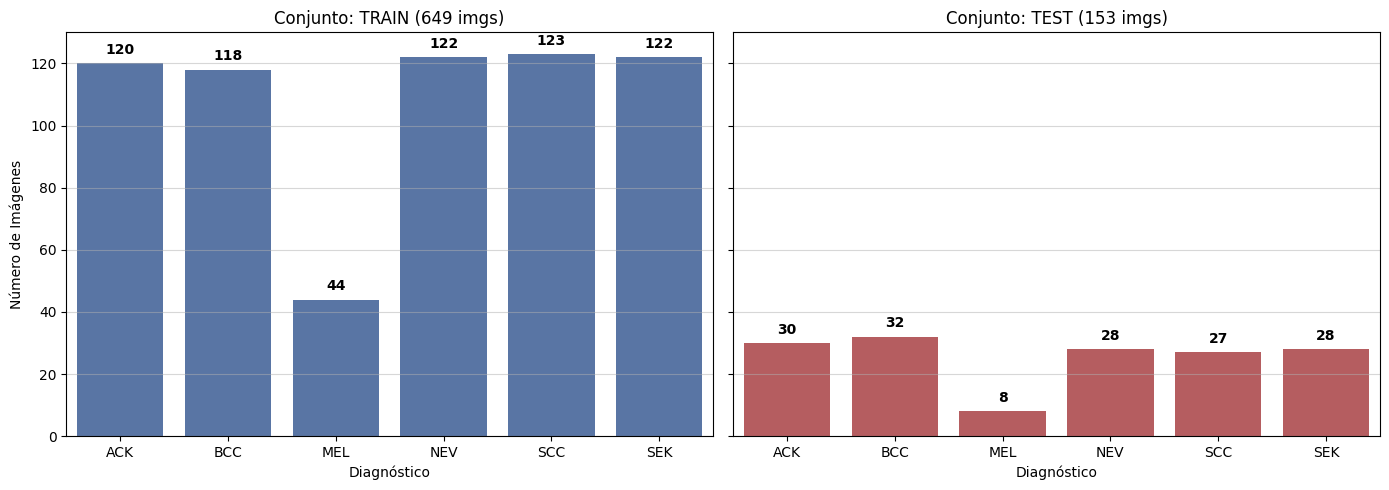


Resumen de Tamaños:
Medio: 890x890
Mínimo: 147x147
Máximo: 3474x3476


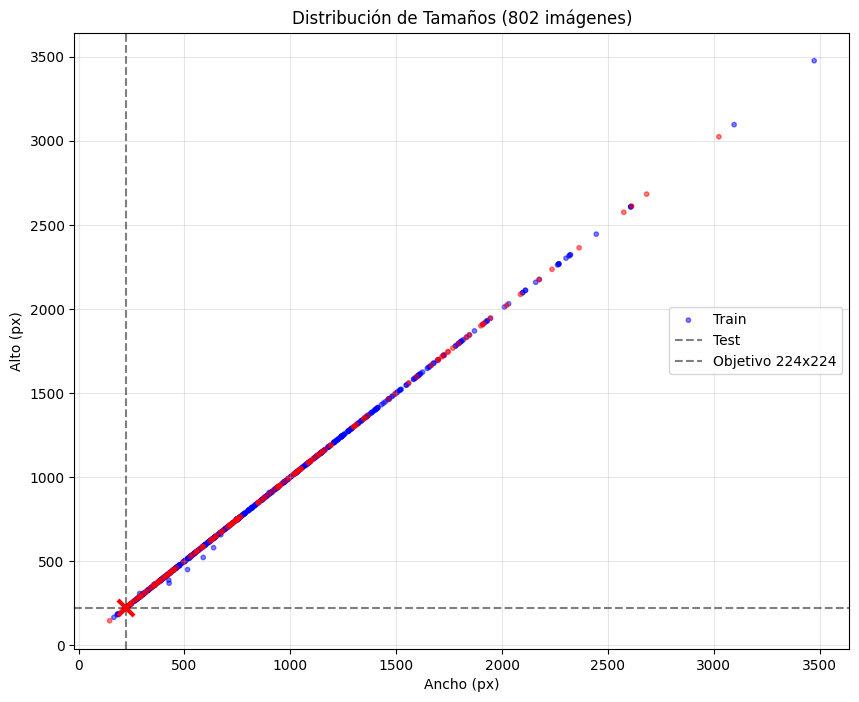

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image
from tqdm import tqdm

RUTA_RAIZ = "../../Datos/images/SPLIT_MULTICLASE"
splits = ["train", "test"]
colores = ["#4c72b0", "#c44e52"]

# --- Distribución de clases ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i, split in enumerate(splits):
    split_path = os.path.join(RUTA_RAIZ, split)
    clases = sorted(os.listdir(split_path))
    conteo = {c: len(os.listdir(os.path.join(split_path, c))) for c in clases}
    total = sum(conteo.values())

    sns.barplot(x=list(conteo.keys()), y=list(conteo.values()), ax=axes[i], color=colores[i])
    axes[i].set_title(f"Conjunto: {split.upper()} ({total} imgs)")
    axes[i].set_xlabel("Diagnóstico")
    axes[i].grid(axis="y", alpha=0.5)
    axes[i].set_ylim(0, 130)

    for idx, (clase, valor) in enumerate(conteo.items()):
        axes[i].text(idx, valor + 3, str(valor), ha="center", fontweight="bold")

axes[0].set_ylabel("Número de Imágenes")
plt.tight_layout()
plt.show()

# --- Tamaño de imágenes ---
anchos = []
altos = []
colores_puntos = []
mapa_colores = {"train": "blue", "test": "red"}

for split in splits:
    split_path = os.path.join(RUTA_RAIZ, split)
    clases = sorted(os.listdir(split_path))
    for clase in clases:
        clase_path = os.path.join(split_path, clase)
        archivos = [f for f in os.listdir(clase_path) if f.lower().endswith((".png", ".jpg", ".jpeg"))]
        for nombre in tqdm(archivos, desc=f"{split}/{clase}", leave=False):
            ruta_completa = os.path.join(clase_path, nombre)
            with Image.open(ruta_completa) as img:
                w, h = img.size
                anchos.append(w)
                altos.append(h)
                colores_puntos.append(mapa_colores[split])

plt.figure(figsize=(10, 8))
plt.scatter(anchos, altos, c=colores_puntos, alpha=0.5, s=10)
plt.axvline(224, color="k", linestyle="--", alpha=0.5)
plt.axhline(224, color="k", linestyle="--", alpha=0.5)
plt.plot(224, 224, "rx", markersize=12, markeredgewidth=3)
plt.title(f"Distribución de Tamaños ({len(anchos)} imágenes)")
plt.xlabel("Ancho (px)")
plt.ylabel("Alto (px)")
plt.legend(["Train", "Test", "Objetivo 224x224"])
plt.grid(True, alpha=0.3)

print(f"\nResumen de Tamaños:")
print(f"Medio: {sum(anchos)//len(anchos)}x{sum(altos)//len(altos)}")
print(f"Mínimo: {min(anchos)}x{min(altos)}")
print(f"Máximo: {max(anchos)}x{max(altos)}")

plt.show()


### Conclusiones del EDA

**Dataset:**
- MEL (Melanoma) es la clase minoritaria, será la más difícil de clasificar
- Train: 649 imgs, Test: 153 imgs
- Dataset pequeño → necesitamos Data Augmentation

**Tamaños:**
- Todas las imágenes tienen proporción similar
- Podemos usar resize directo a 224x224

## 2. Carga de Datos y Data Augmentation

In [3]:
import torch
from torchvision import datasets
from torch.utils.data import DataLoader, Dataset
from ultralytics.data.augment import classify_augmentations, classify_transforms
from sklearn.model_selection import StratifiedKFold
import random
import numpy as np

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

RUTA_BASE = "../../Datos/images/SPLIT_MULTICLASE"
BATCH_SIZE = 64
IMG_SIZE = 224
K_FOLDS = 5
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

# Pipeline de entrenamiento con augmentation
train_pipeline = classify_augmentations(
    size=IMG_SIZE,
    mean=MEAN,
    std=STD,
    scale=(0.5, 1.0),
    hflip=0.5,
    vflip=0.5,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    erasing=0.3,
)

# Pipeline de validacion/test (determinista)
val_test_pipeline = classify_transforms(
    size=IMG_SIZE,
    mean=MEAN,
    std=STD,
    interpolation="BILINEAR"
)

# Dataset de train COMPLETO sin transform (se asigna por fold)
full_train_dataset = datasets.ImageFolder(
    f"{RUTA_BASE}/train",
    transform=None
)
targets = full_train_dataset.targets
print(f"Train total: {len(full_train_dataset)} imgs, Clases: {full_train_dataset.classes}")

# Dataset de test (fijo, no cambia entre folds)
test_dataset = datasets.ImageFolder(
    f"{RUTA_BASE}/test",
    transform=val_test_pipeline
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)
print(f"Test: {len(test_dataset)} imgs")

# Wrapper para aplicar transform distinto a cada subset
class SubsetConTransform(Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset = dataset
        self.indices = list(indices)
        self.transform = transform

    def __getitem__(self, idx):
        img, label = self.dataset[self.indices[idx]]
        if self.transform is not None:
            img = self.transform(img)
        return img, label

    def __len__(self):
        return len(self.indices)

# Objeto KFold estratificado
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

print(f"\n5-Fold CV preparado. En cada fold:")
for fold, (train_idx, val_idx) in enumerate(skf.split(range(len(targets)), targets)):
    print(f"  Fold {fold+1}: train={len(train_idx)}, val={len(val_idx)}")

Train total: 649 imgs, Clases: ['ACK', 'BCC', 'MEL', 'NEV', 'SCC', 'SEK']
Test: 153 imgs

5-Fold CV preparado. En cada fold:
  Fold 1: train=519, val=130
  Fold 2: train=519, val=130
  Fold 3: train=519, val=130
  Fold 4: train=519, val=130
  Fold 5: train=520, val=129


### Visualización del Data Augmentation

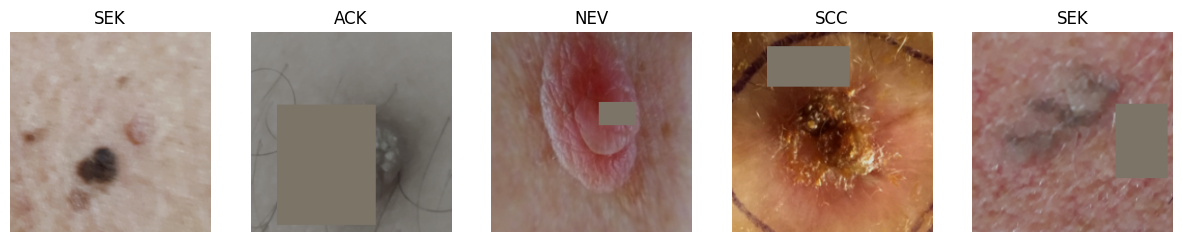

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

# Loader temporal con el pipeline de augmentation para visualizar
viz_dataset = datasets.ImageFolder(f"{RUTA_BASE}/train", transform=train_pipeline)
viz_loader = DataLoader(viz_dataset, batch_size=BATCH_SIZE, shuffle=True)
imgs, labels = next(iter(viz_loader))

def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = tensor.permute(1, 2, 0).numpy()
    return np.clip(img * std + mean, 0, 1)

plt.figure(figsize=(15, 5))
for i in range(5):
    ax = plt.subplot(1, 5, i+1)
    plt.imshow(denormalize(imgs[i]))
    plt.title(full_train_dataset.classes[labels[i]])
    plt.axis("off")
plt.show()

del viz_dataset, viz_loader

## 3. Funciones de Entrenamiento y Evaluación

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import copy
import torch
import torch.nn as nn
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.metrics import (
    f1_score, confusion_matrix, classification_report,
    accuracy_score, cohen_kappa_score, precision_score, recall_score
)

# ============================================================
# FUNCIONES AUXILIARES
# ============================================================

def obtener_predicciones(model, loader, device):
    """Obtiene predicciones, etiquetas reales y probabilidades de un modelo."""
    model.eval()
    y_true, y_pred, y_probs = [], [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())
    return np.array(y_true), np.array(y_pred), np.array(y_probs)


def calcular_metricas(y_true, y_pred):
    """Calcula todas las metricas a partir de etiquetas reales y predichas."""
    return {
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'precision_weighted': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_weighted': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'kappa': cohen_kappa_score(y_true, y_pred),
    }


def mostrar_reporte_completo(y_true, y_pred, classes, titulo):
    """Muestra matriz de confusion, classification report y todas las metricas."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Matriz de Confusion - {titulo}')
    plt.ylabel('Etiqueta Real')
    plt.xlabel('Prediccion')
    plt.show()

    metricas = calcular_metricas(y_true, y_pred)

    print(f"\n{'='*70}")
    print(f"REPORTE: {titulo}")
    print(f"{'='*70}")
    print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))
    print(f"{'─'*70}")
    print(f"  Accuracy:           {metricas['accuracy']:.4f}")
    print(f"  F1 Macro:           {metricas['f1_macro']:.4f}")
    print(f"  F1 Weighted:        {metricas['f1_weighted']:.4f}")
    print(f"  Precision Macro:    {metricas['precision_macro']:.4f}")
    print(f"  Precision Weighted: {metricas['precision_weighted']:.4f}")
    print(f"  Recall Macro:       {metricas['recall_macro']:.4f}")
    print(f"  Recall Weighted:    {metricas['recall_weighted']:.4f}")
    print(f"  Cohen's Kappa:      {metricas['kappa']:.4f}")
    print(f"{'='*70}")

    return metricas


# ============================================================
# FUNCIONES DE VISUALIZACION
# ============================================================

def plot_training_history(historial, titulo=""):
    """Curvas de entrenamiento de un solo run."""
    epochs = range(1, len(historial['train_loss']) + 1)

    plt.figure(figsize=(15, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, historial['train_loss'], label='Train Loss', color='blue', linewidth=2)
    plt.plot(epochs, historial['val_loss'], label='Val Loss', color='orange', linestyle='--', linewidth=2)
    plt.title(f'Loss - {titulo}')
    plt.xlabel('Epocas')
    plt.ylabel('CrossEntropy Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, historial['val_f1'], label='Val F1 (Macro)', color='green', marker='o', linewidth=2)
    plt.axhline(y=max(historial['val_f1']), color='r', linestyle=':', label=f'Mejor: {max(historial["val_f1"]):.4f}')
    plt.title(f'F1-Score - {titulo}')
    plt.xlabel('Epocas')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_kfold_history(historiales, nombre_exp):
    """Curvas promediadas de K folds con banda de desviacion estandar."""
    max_epochs = max(len(h['train_loss']) for h in historiales)

    def pad(lst, length):
        return lst + [lst[-1]] * (length - len(lst))

    train_losses = np.array([pad(h['train_loss'], max_epochs) for h in historiales])
    val_losses = np.array([pad(h['val_loss'], max_epochs) for h in historiales])
    val_f1s = np.array([pad(h['val_f1'], max_epochs) for h in historiales])

    epochs = range(1, max_epochs + 1)
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Loss
    ax = axes[0]
    mean_tl, std_tl = train_losses.mean(axis=0), train_losses.std(axis=0)
    mean_vl, std_vl = val_losses.mean(axis=0), val_losses.std(axis=0)
    ax.plot(epochs, mean_tl, 'b-', linewidth=2, label='Train Loss (media)')
    ax.fill_between(epochs, mean_tl - std_tl, mean_tl + std_tl, alpha=0.2, color='blue')
    ax.plot(epochs, mean_vl, 'r--', linewidth=2, label='Val Loss (media)')
    ax.fill_between(epochs, mean_vl - std_vl, mean_vl + std_vl, alpha=0.2, color='red')
    ax.set_title(f'Loss Promedio - {nombre_exp}')
    ax.set_xlabel('Epocas')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # F1
    ax = axes[1]
    mean_f1, std_f1 = val_f1s.mean(axis=0), val_f1s.std(axis=0)
    ax.plot(epochs, mean_f1, 'g-', linewidth=2, label='Val F1 Macro (media)')
    ax.fill_between(epochs, mean_f1 - std_f1, mean_f1 + std_f1, alpha=0.2, color='green')
    ax.set_title(f'F1-Score Promedio - {nombre_exp}')
    ax.set_xlabel('Epocas')
    ax.set_ylabel('F1 Score')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# ============================================================
# FUNCION DE ENTRENAMIENTO (un fold)
# ============================================================

def entrenar_modelo(model, train_loader, val_loader, criterion, optimizer, device, epochs=25, nombre_archivo="mejor_modelo.pth"):
    """Entrena un modelo y guarda el mejor segun F1 macro en validacion."""
    historial = {'train_loss': [], 'val_loss': [], 'val_f1': []}
    best_f1 = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        # Train
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)

        # Validation
        model.eval()
        val_loss = 0.0
        y_true, y_pred = [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                y_true.extend(labels.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())

        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_f1 = f1_score(y_true, y_pred, average='macro')

        historial['train_loss'].append(epoch_train_loss)
        historial['val_loss'].append(epoch_val_loss)
        historial['val_f1'].append(epoch_val_f1)

        marcador = ""
        if epoch_val_f1 > best_f1:
            best_f1 = epoch_val_f1
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), nombre_archivo)
            marcador = " ** Mejor!"

        print(f"  Ep {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.3f} | Val Loss: {epoch_val_loss:.3f} | Val F1: {epoch_val_f1:.4f}{marcador}")

    print(f"  Mejor F1 Val: {best_f1:.4f}")
    model.load_state_dict(best_model_wts)
    return model, historial


# ============================================================
# PIPELINE COMPLETO 5-FOLD CV
# ============================================================

def lanzar_experimento_kfold(crear_modelo_fn, nombre_exp, device, epochs=25):
    """
    Ejecuta el pipeline completo de 5-Fold Cross-Validation.

    Args:
        crear_modelo_fn: funcion(num_classes, device) -> (model, optimizer)
        nombre_exp: nombre del experimento
        device: torch device
        epochs: epocas por fold

    Usa variables globales: full_train_dataset, targets, skf,
        train_pipeline, val_test_pipeline, test_loader,
        BATCH_SIZE, SubsetConTransform
    """
    print(f"\n{'='*60}")
    print(f"EXPERIMENTO 5-FOLD CV: {nombre_exp}")
    print(f"{'='*60}")

    num_classes = len(full_train_dataset.classes)
    classes = full_train_dataset.classes

    metricas_folds = []
    historiales = []
    modelos_state_dicts = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(range(len(targets)), targets)):
        print(f"\n{'─'*50}")
        print(f"FOLD {fold+1}/{skf.n_splits} | Train: {len(train_idx)} | Val: {len(val_idx)}")
        print(f"{'─'*50}")

        # --- DataLoaders del fold ---
        fold_train = SubsetConTransform(full_train_dataset, train_idx, train_pipeline)
        fold_val = SubsetConTransform(full_train_dataset, val_idx, val_test_pipeline)

        fold_train_loader = DataLoader(
            fold_train, batch_size=BATCH_SIZE, shuffle=True,
            num_workers=8, pin_memory=True
        )
        fold_val_loader = DataLoader(
            fold_val, batch_size=BATCH_SIZE, shuffle=False,
            num_workers=4, pin_memory=True
        )

        # --- Pesos de clase para este fold ---
        fold_targets = [targets[i] for i in train_idx]
        class_counts = np.bincount(fold_targets, minlength=num_classes).astype(float)
        weights = 1.0 / class_counts
        weights = weights / weights.sum() * num_classes
        class_weights = torch.FloatTensor(weights).to(device)
        criterion = nn.CrossEntropyLoss(weight=class_weights)

        # --- Modelo y optimizador frescos ---
        model, optimizer = crear_modelo_fn(num_classes, device)

        # --- Entrenar ---
        model, historial = entrenar_modelo(
            model, fold_train_loader, fold_val_loader,
            criterion, optimizer, device, epochs,
            nombre_archivo=f"{nombre_exp}_fold{fold+1}.pth"
        )

        # --- Metricas del fold en validacion ---
        y_true, y_pred, _ = obtener_predicciones(model, fold_val_loader, device)
        fold_metricas = calcular_metricas(y_true, y_pred)

        print(f"  >> Fold {fold+1} Val: F1={fold_metricas['f1_macro']:.4f} | "
              f"Acc={fold_metricas['accuracy']:.4f} | Kappa={fold_metricas['kappa']:.4f}")

        metricas_folds.append(fold_metricas)
        historiales.append(historial)
        modelos_state_dicts.append(copy.deepcopy(model.state_dict()))

    # ============================================================
    # RESUMEN CROSS-VALIDATION
    # ============================================================
    print(f"\n{'='*60}")
    print(f"RESUMEN 5-FOLD CV: {nombre_exp}")
    print(f"{'='*60}")

    metric_names = ['f1_macro', 'f1_weighted', 'accuracy',
                    'precision_macro', 'precision_weighted',
                    'recall_macro', 'recall_weighted', 'kappa']

    tabla = {}
    for metric in metric_names:
        valores = [m[metric] for m in metricas_folds]
        tabla[metric] = [round(v, 4) for v in valores] + [round(np.mean(valores), 4), round(np.std(valores), 4)]

    cols = [f"Fold {i+1}" for i in range(skf.n_splits)] + ["Media", "Std"]
    df_resumen = pd.DataFrame(tabla, index=cols).T
    print(df_resumen.to_string())

    # --- Curvas promediadas ---
    print(f"\nCurvas de entrenamiento promediadas:")
    plot_kfold_history(historiales, nombre_exp)

    # --- Curvas individuales por fold ---
    for i, h in enumerate(historiales):
        plot_training_history(h, titulo=f"{nombre_exp} - Fold {i+1}")

    # ============================================================
    # EVALUACION EN TEST: MEJOR MODELO (fold con mejor F1 val)
    # ============================================================
    f1_scores = [m['f1_macro'] for m in metricas_folds]
    best_fold = int(np.argmax(f1_scores))

    print(f"\nMejor fold: {best_fold+1} (F1 Macro Val = {f1_scores[best_fold]:.4f})")

    print(f"\n{'='*60}")
    print(f"TEST - MEJOR MODELO (Fold {best_fold+1}) - {nombre_exp}")
    print(f"{'='*60}")

    model_best, _ = crear_modelo_fn(num_classes, device)
    model_best.load_state_dict(modelos_state_dicts[best_fold])

    y_true_test, y_pred_test, _ = obtener_predicciones(model_best, test_loader, device)
    metricas_test_best = mostrar_reporte_completo(
        y_true_test, y_pred_test, classes,
        f"TEST - Mejor Modelo (Fold {best_fold+1}) - {nombre_exp}"
    )

    # ============================================================
    # EVALUACION EN TEST: ENSEMBLE DE FOLDS (media de probabilidades)
    # ============================================================
    print(f"\n{'='*60}")
    print(f"TEST - ENSEMBLE {skf.n_splits} FOLDS - {nombre_exp}")
    print(f"{'='*60}")

    all_probs = []
    for i, state_dict in enumerate(modelos_state_dicts):
        model_i, _ = crear_modelo_fn(num_classes, device)
        model_i.load_state_dict(state_dict)
        _, _, probs_i = obtener_predicciones(model_i, test_loader, device)
        all_probs.append(probs_i)

    mean_probs = np.mean(all_probs, axis=0)
    y_pred_ensemble = np.argmax(mean_probs, axis=1)

    metricas_test_ensemble = mostrar_reporte_completo(
        y_true_test, y_pred_ensemble, classes,
        f"TEST - Ensemble {skf.n_splits} Folds - {nombre_exp}"
    )

    # ============================================================
    # COMPARATIVA FINAL: MEJOR MODELO vs ENSEMBLE
    # ============================================================
    print(f"\n{'='*60}")
    print(f"COMPARATIVA TEST: Mejor Fold vs Ensemble - {nombre_exp}")
    print(f"{'='*60}")

    comp = pd.DataFrame({
        f'Mejor (Fold {best_fold+1})': metricas_test_best,
        f'Ensemble ({skf.n_splits} Folds)': metricas_test_ensemble
    }).T
    print(comp.round(4).to_string())
    print(f"{'='*60}")

    return {
        'metricas_folds': metricas_folds,
        'historiales': historiales,
        'modelos_state_dicts': modelos_state_dicts,
        'best_fold': best_fold,
        'metricas_test_best': metricas_test_best,
        'metricas_test_ensemble': metricas_test_ensemble,
        'df_resumen': df_resumen,
    }


print("Funciones cargadas.")

Funciones cargadas.


## 4. Modelo 1: ResNet-18

ResNet utiliza conexiones residuales (skip connections) que permiten entrenar redes profundas sin degradación del gradiente.

Usando device: cuda

EXPERIMENTO 5-FOLD CV: ResNet18_5Fold

──────────────────────────────────────────────────
FOLD 1/5 | Train: 519 | Val: 130
──────────────────────────────────────────────────
  Ep 1/25 | Train Loss: 1.981 | Val Loss: 1.659 | Val F1: 0.2697 ** Mejor!
  Ep 2/25 | Train Loss: 1.590 | Val Loss: 1.436 | Val F1: 0.4356 ** Mejor!
  Ep 3/25 | Train Loss: 1.466 | Val Loss: 1.337 | Val F1: 0.4410 ** Mejor!
  Ep 4/25 | Train Loss: 1.284 | Val Loss: 1.227 | Val F1: 0.4983 ** Mejor!
  Ep 5/25 | Train Loss: 1.182 | Val Loss: 1.217 | Val F1: 0.5193 ** Mejor!
  Ep 6/25 | Train Loss: 1.217 | Val Loss: 1.204 | Val F1: 0.4887
  Ep 7/25 | Train Loss: 1.123 | Val Loss: 1.189 | Val F1: 0.4836
  Ep 8/25 | Train Loss: 1.097 | Val Loss: 1.198 | Val F1: 0.5188
  Ep 9/25 | Train Loss: 0.994 | Val Loss: 1.121 | Val F1: 0.5428 ** Mejor!
  Ep 10/25 | Train Loss: 0.959 | Val Loss: 1.107 | Val F1: 0.5444 ** Mejor!
  Ep 11/25 | Train Loss: 0.916 | Val Loss: 1.160 | Val F1: 0.5453 ** Mejor!
  Ep 12/

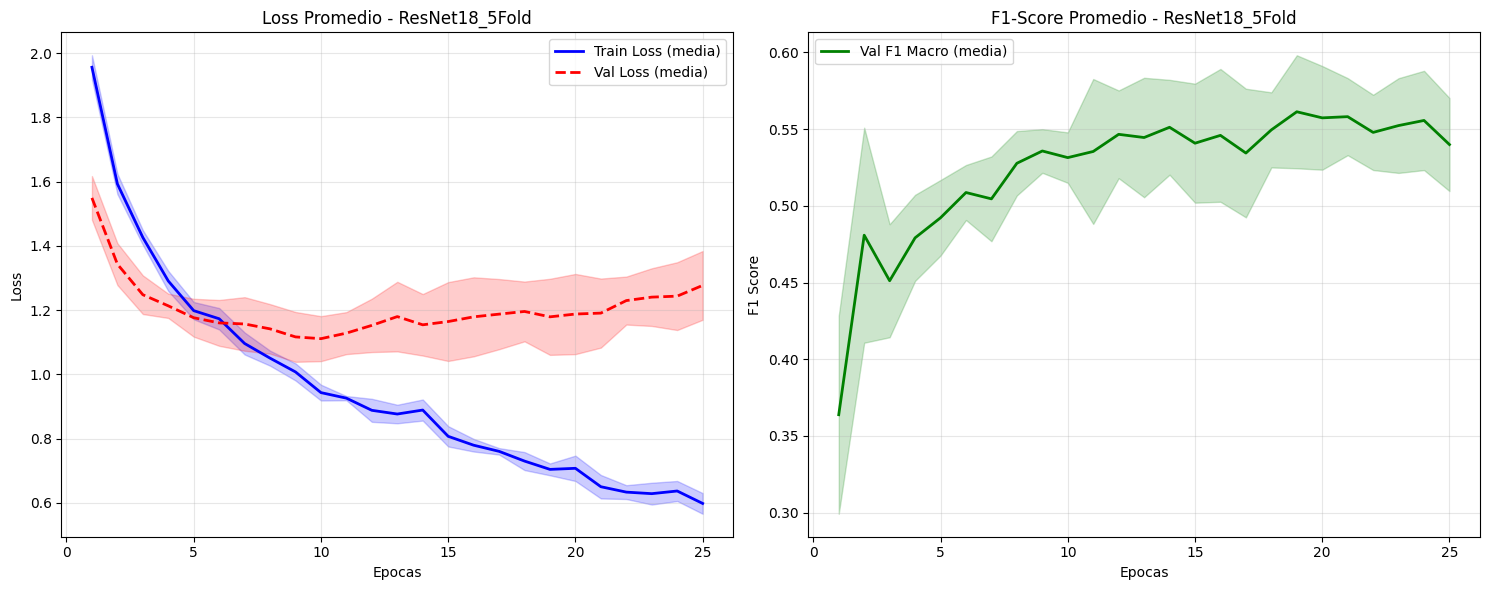

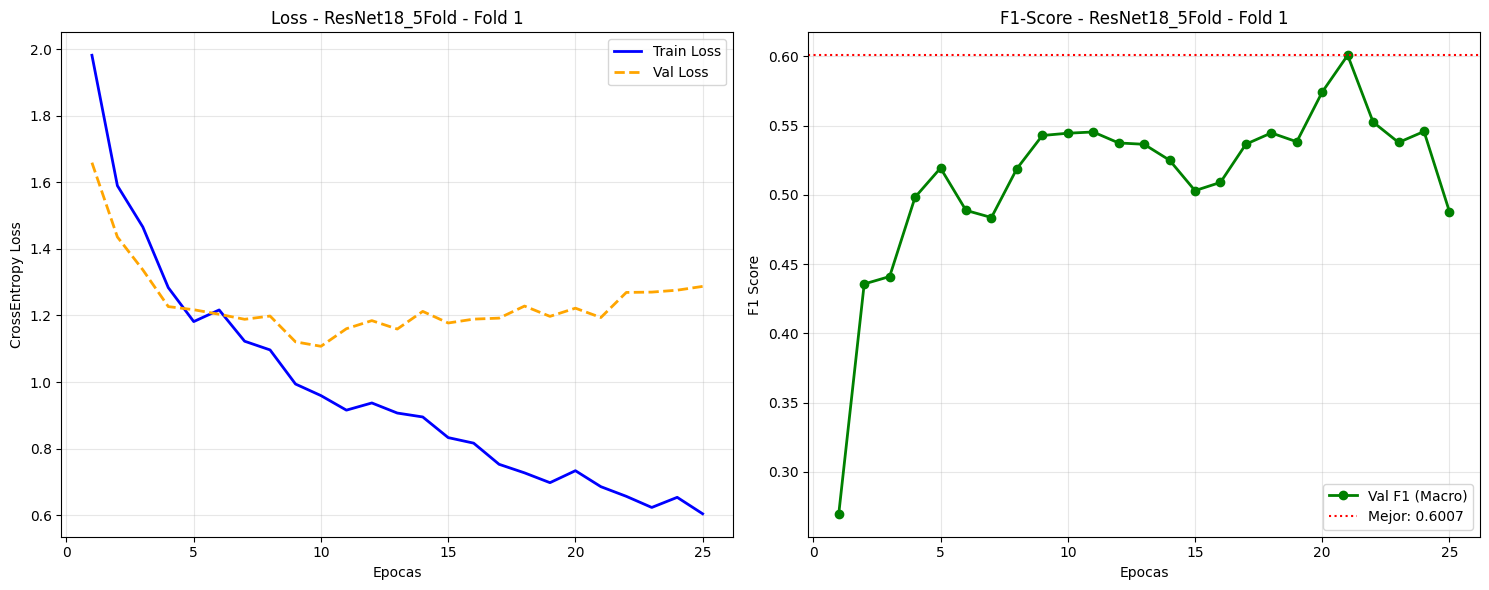

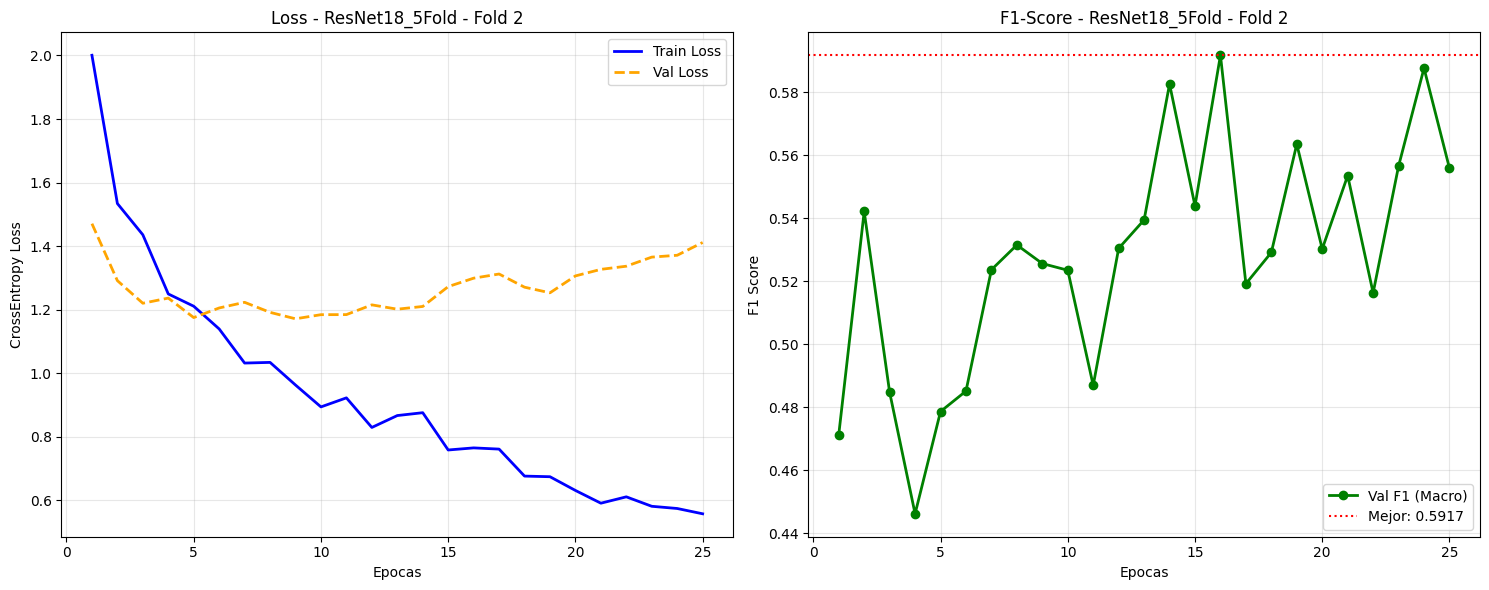

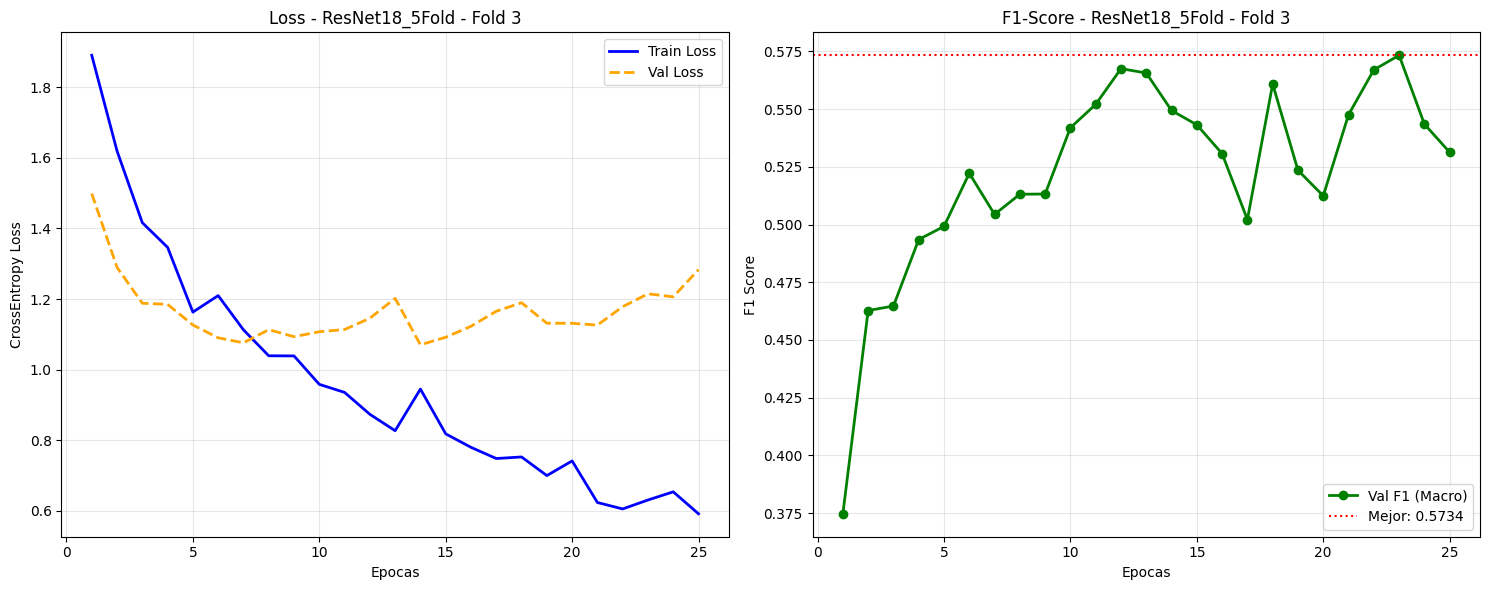

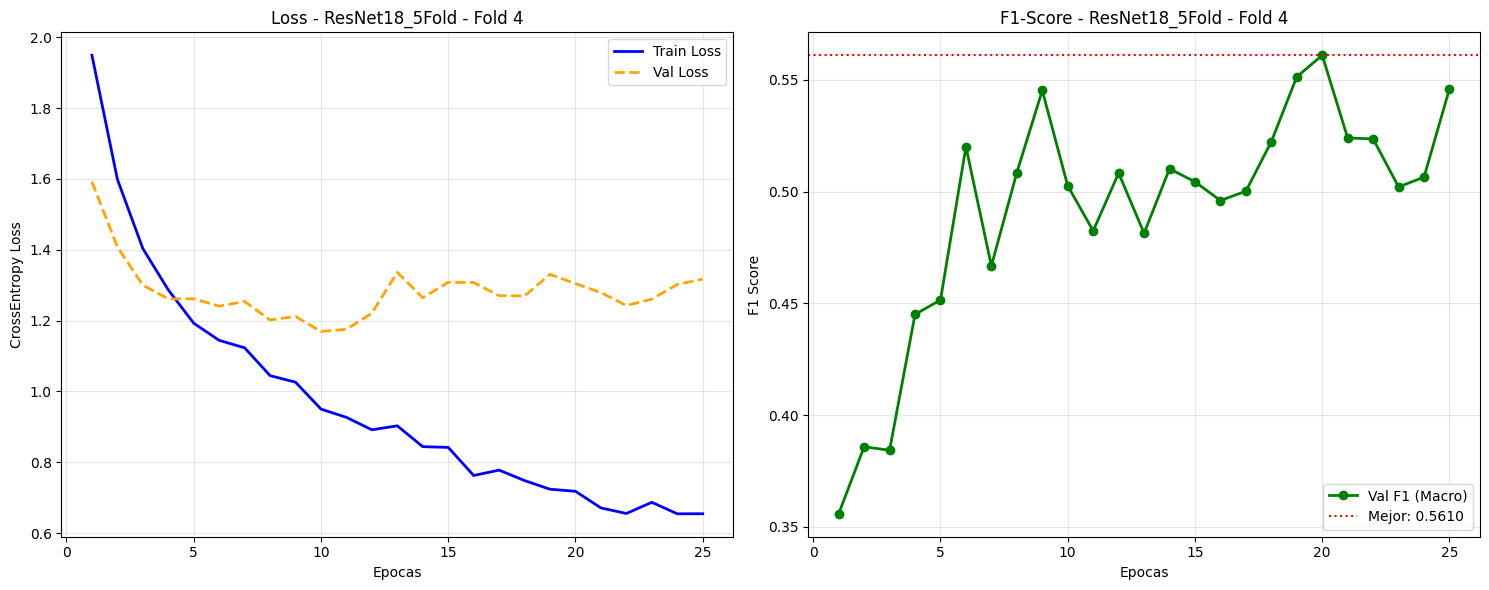

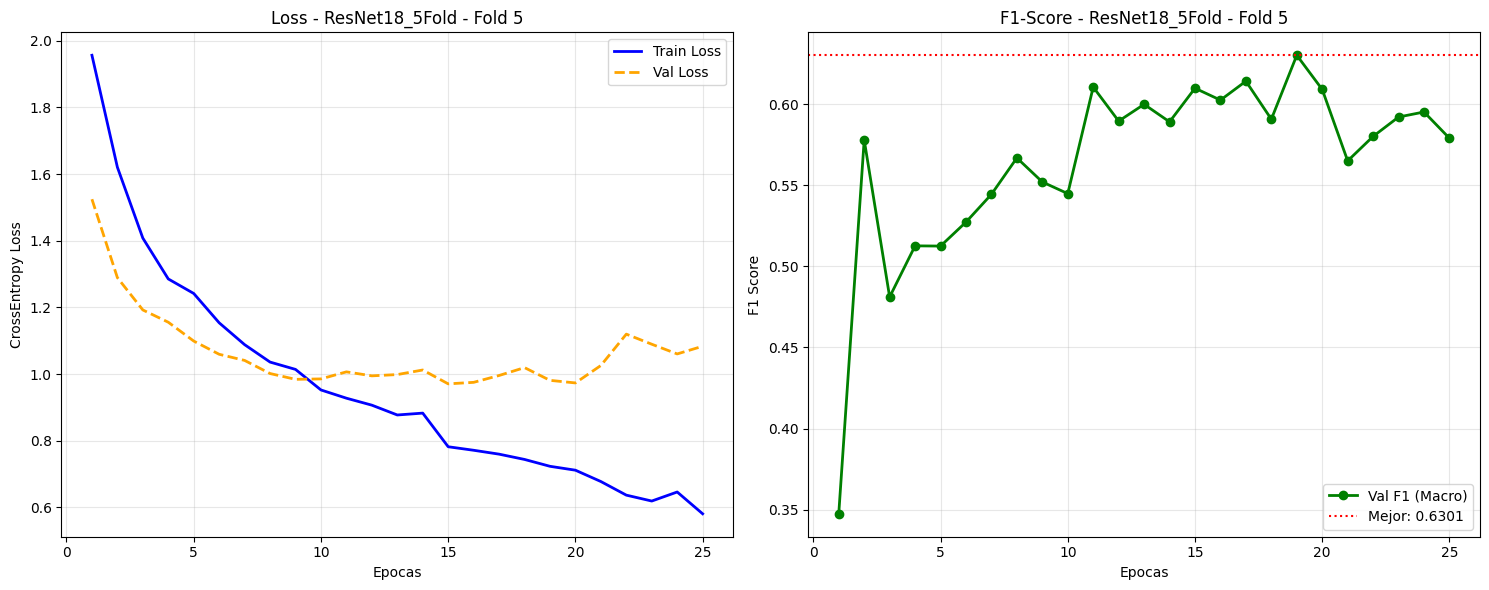


Mejor fold: 5 (F1 Macro Val = 0.6301)

TEST - MEJOR MODELO (Fold 5) - ResNet18_5Fold


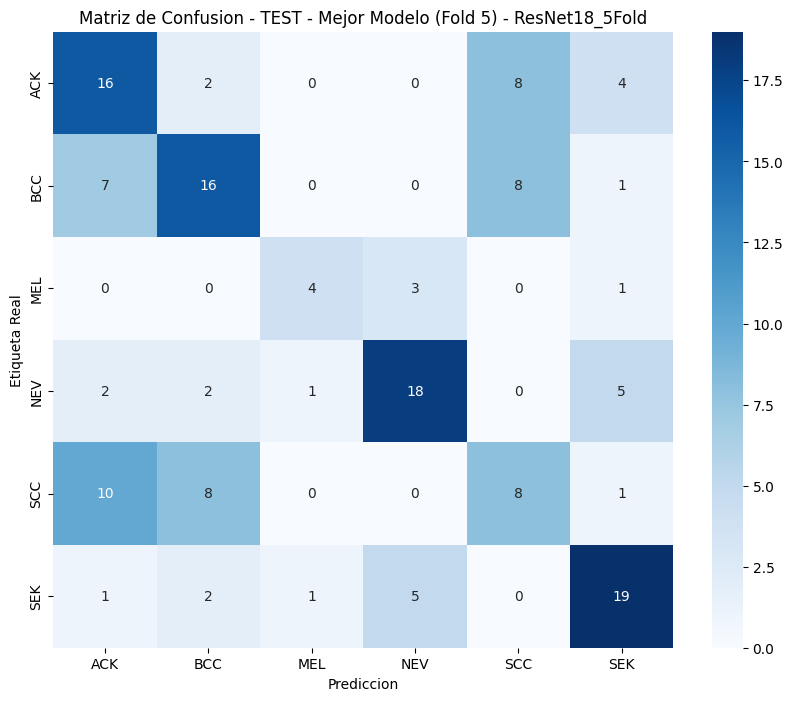


REPORTE: TEST - Mejor Modelo (Fold 5) - ResNet18_5Fold
              precision    recall  f1-score   support

         ACK       0.44      0.53      0.48        30
         BCC       0.53      0.50      0.52        32
         MEL       0.67      0.50      0.57         8
         NEV       0.69      0.64      0.67        28
         SCC       0.33      0.30      0.31        27
         SEK       0.61      0.68      0.64        28

    accuracy                           0.53       153
   macro avg       0.55      0.53      0.53       153
weighted avg       0.53      0.53      0.53       153

──────────────────────────────────────────────────────────────────────
  Accuracy:           0.5294
  F1 Macro:           0.5328
  F1 Weighted:        0.5281
  Precision Macro:    0.5472
  Precision Weighted: 0.5312
  Recall Macro:       0.5252
  Recall Weighted:    0.5294
  Cohen's Kappa:      0.4226

TEST - ENSEMBLE 5 FOLDS - ResNet18_5Fold


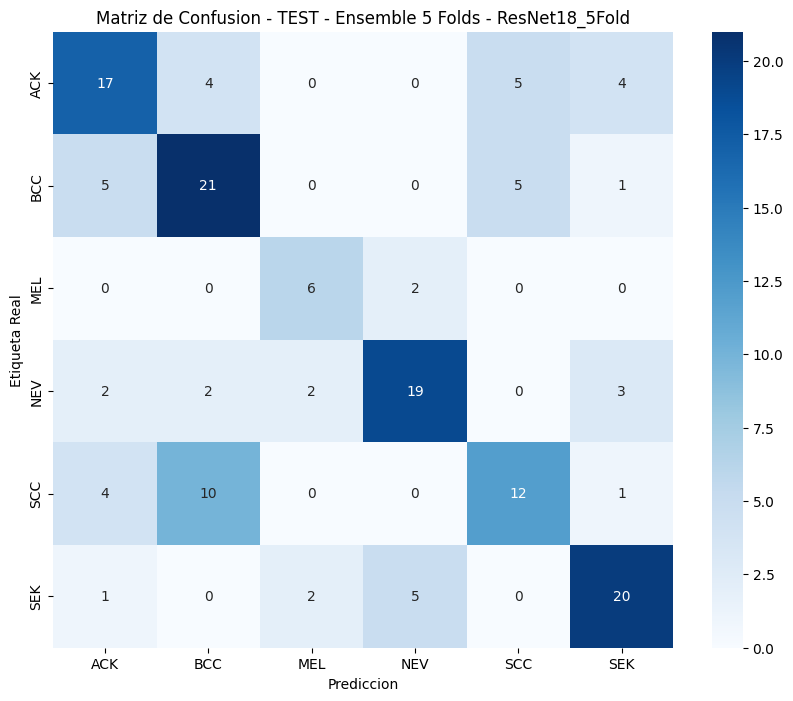


REPORTE: TEST - Ensemble 5 Folds - ResNet18_5Fold
              precision    recall  f1-score   support

         ACK       0.59      0.57      0.58        30
         BCC       0.57      0.66      0.61        32
         MEL       0.60      0.75      0.67         8
         NEV       0.73      0.68      0.70        28
         SCC       0.55      0.44      0.49        27
         SEK       0.69      0.71      0.70        28

    accuracy                           0.62       153
   macro avg       0.62      0.64      0.62       153
weighted avg       0.62      0.62      0.62       153

──────────────────────────────────────────────────────────────────────
  Accuracy:           0.6209
  F1 Macro:           0.6245
  F1 Weighted:        0.6188
  Precision Macro:    0.6199
  Precision Weighted: 0.6212
  Recall Macro:       0.6350
  Recall Weighted:    0.6209
  Cohen's Kappa:      0.5364

COMPARATIVA TEST: Mejor Fold vs Ensemble - ResNet18_5Fold
                    f1_macro  f1_weighted  a

In [6]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando device:", device)


def crear_resnet18(num_classes, device):
    
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    for param in model.parameters():
        param.requires_grad = False
    for param in model.layer4.parameters():
        param.requires_grad = True
    num_ftrs = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_ftrs, num_classes)
        )
    model = model.to(device)

    optimizer = optim.AdamW([
        {'params': model.layer4.parameters(), 'lr': 1e-4},
        {'params': model.fc.parameters(), 'lr': 1e-3}
    ], weight_decay=0.01)

    return model, optimizer


resultados_resnet = lanzar_experimento_kfold(
    crear_modelo_fn=crear_resnet18,
    nombre_exp="ResNet18_5Fold",
    device=device,
    epochs=25
)

## 6. Modelo 3: DenseNet-121

DenseNet conecta cada capa con todas las anteriores mediante conexiones densas, reutilizando features de forma eficiente.

Usando device: cuda

EXPERIMENTO 5-FOLD CV: DenseNet121_5Fold

──────────────────────────────────────────────────
FOLD 1/5 | Train: 519 | Val: 130
──────────────────────────────────────────────────
  Ep 1/25 | Train Loss: 1.828 | Val Loss: 1.669 | Val F1: 0.2761 ** Mejor!
  Ep 2/25 | Train Loss: 1.720 | Val Loss: 1.530 | Val F1: 0.3424 ** Mejor!
  Ep 3/25 | Train Loss: 1.495 | Val Loss: 1.479 | Val F1: 0.3353
  Ep 4/25 | Train Loss: 1.418 | Val Loss: 1.401 | Val F1: 0.4570 ** Mejor!
  Ep 5/25 | Train Loss: 1.342 | Val Loss: 1.331 | Val F1: 0.4044
  Ep 6/25 | Train Loss: 1.271 | Val Loss: 1.289 | Val F1: 0.4903 ** Mejor!
  Ep 7/25 | Train Loss: 1.238 | Val Loss: 1.258 | Val F1: 0.5282 ** Mejor!
  Ep 8/25 | Train Loss: 1.160 | Val Loss: 1.223 | Val F1: 0.4975
  Ep 9/25 | Train Loss: 1.121 | Val Loss: 1.210 | Val F1: 0.5312 ** Mejor!
  Ep 10/25 | Train Loss: 1.117 | Val Loss: 1.190 | Val F1: 0.5375 ** Mejor!
  Ep 11/25 | Train Loss: 1.069 | Val Loss: 1.188 | Val F1: 0.5085
  Ep 12/25 | Tr

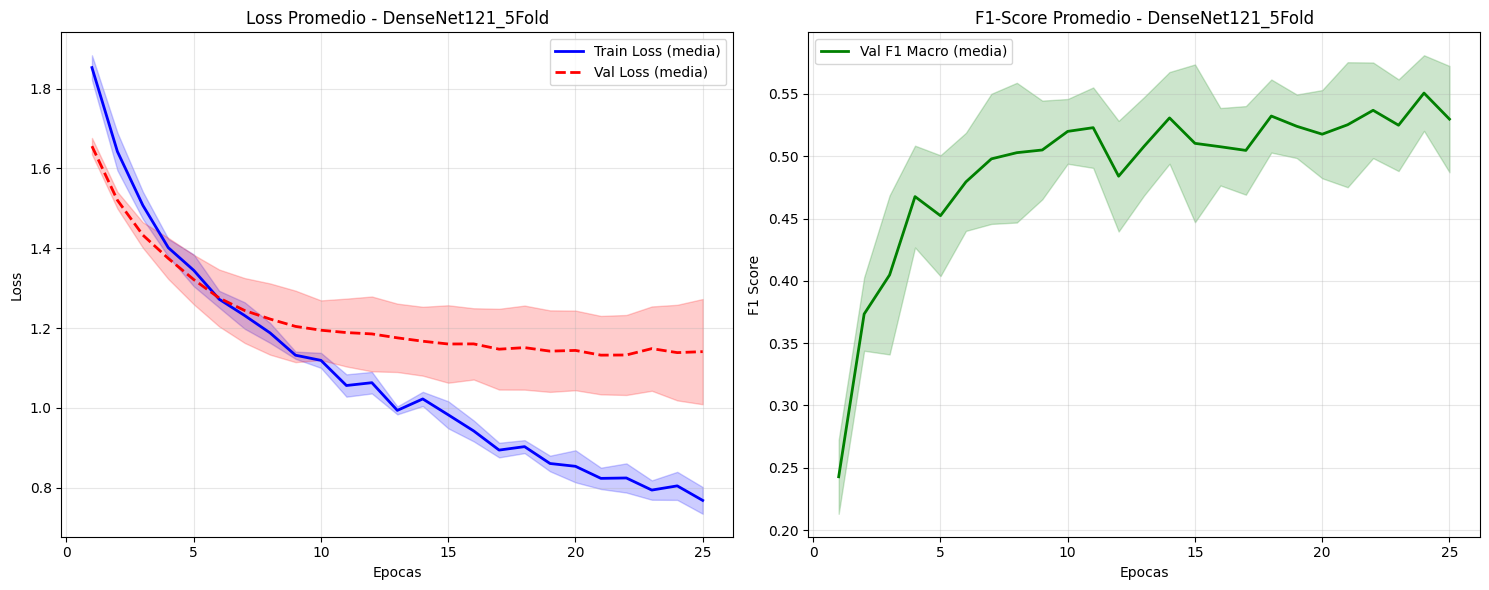

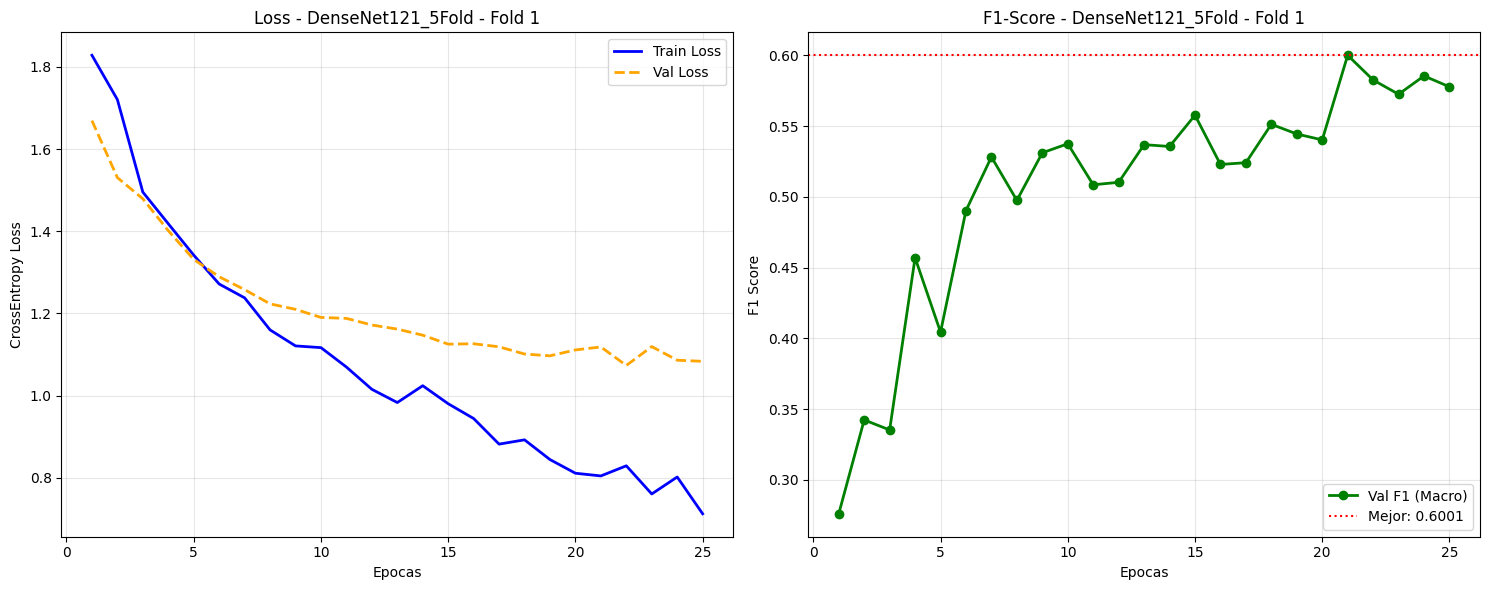

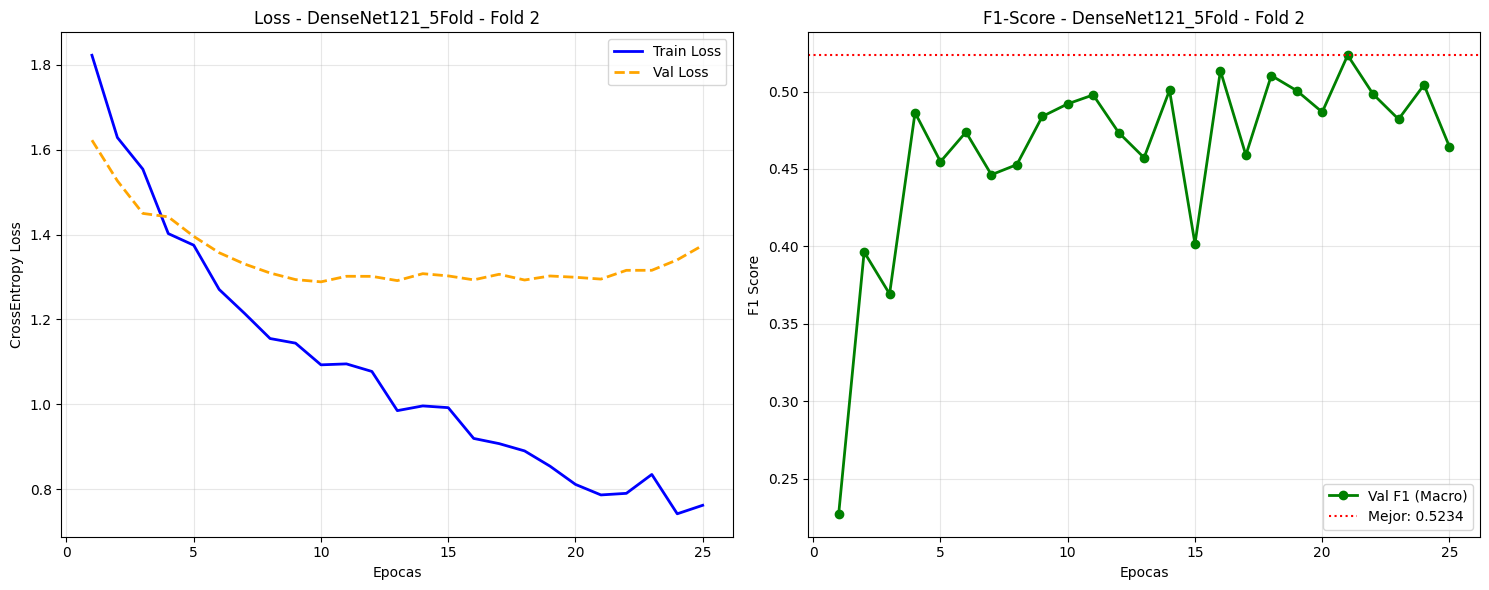

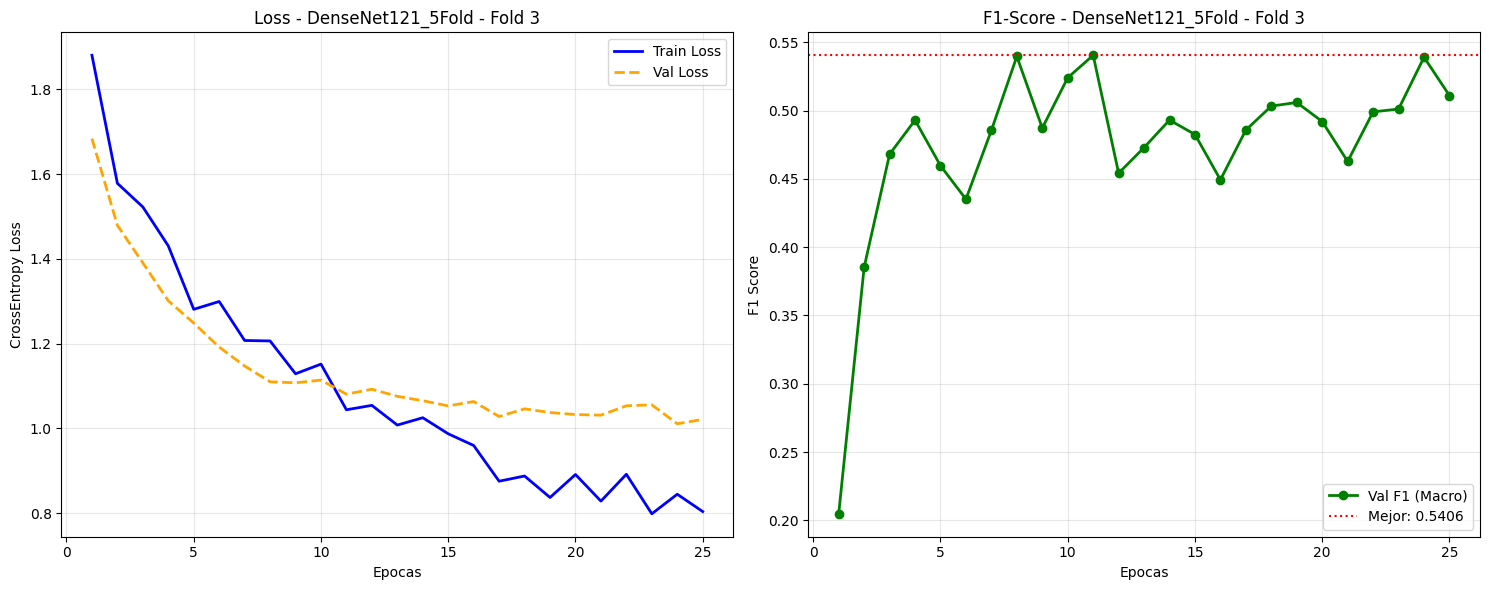

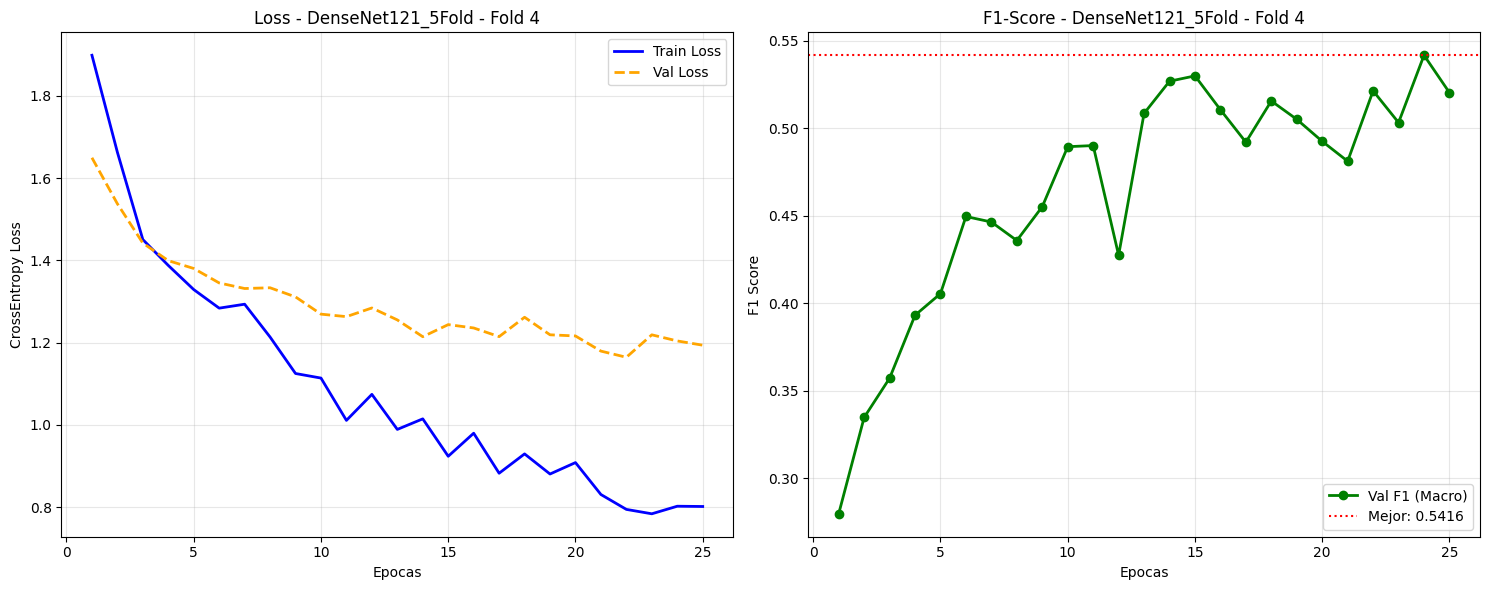

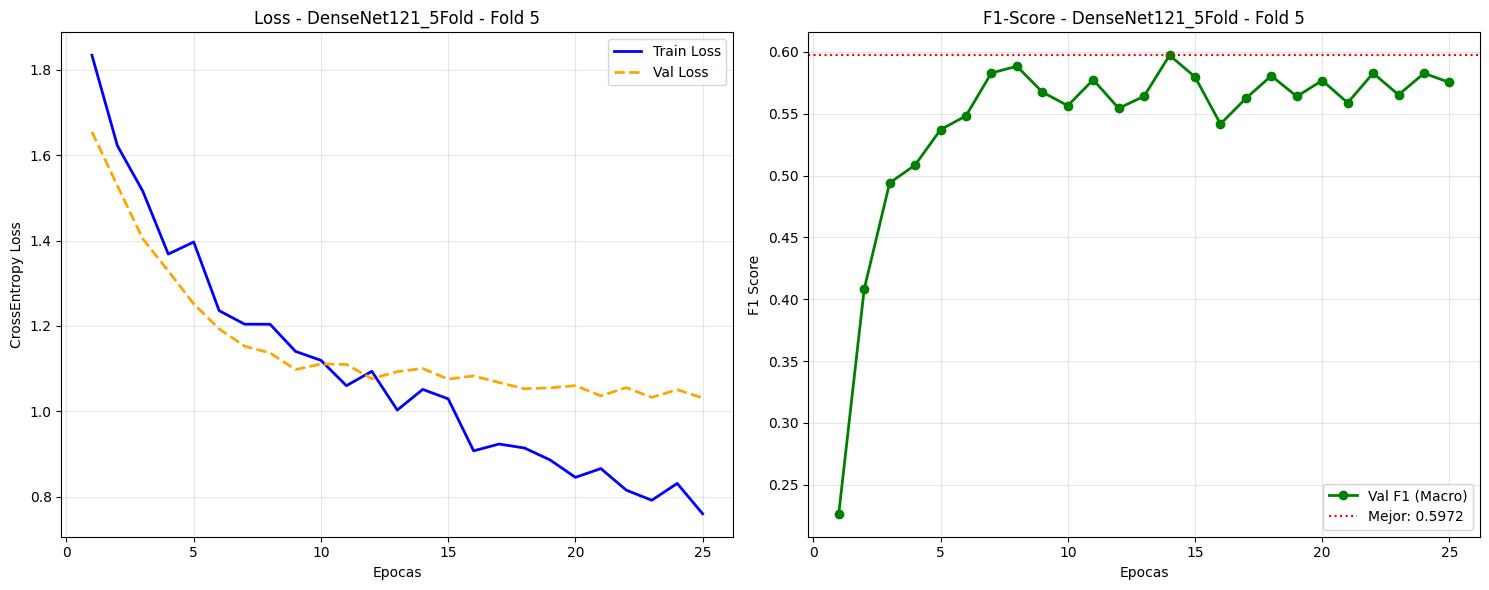


Mejor fold: 1 (F1 Macro Val = 0.6001)

TEST - MEJOR MODELO (Fold 1) - DenseNet121_5Fold


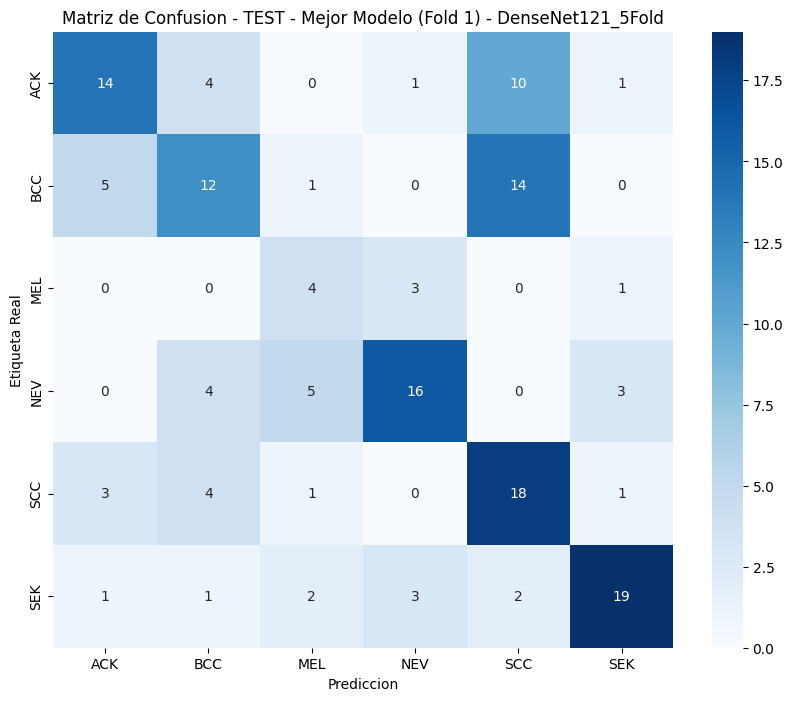


REPORTE: TEST - Mejor Modelo (Fold 1) - DenseNet121_5Fold
              precision    recall  f1-score   support

         ACK       0.61      0.47      0.53        30
         BCC       0.48      0.38      0.42        32
         MEL       0.31      0.50      0.38         8
         NEV       0.70      0.57      0.63        28
         SCC       0.41      0.67      0.51        27
         SEK       0.76      0.68      0.72        28

    accuracy                           0.54       153
   macro avg       0.54      0.54      0.53       153
weighted avg       0.57      0.54      0.55       153

──────────────────────────────────────────────────────────────────────
  Accuracy:           0.5425
  F1 Macro:           0.5303
  F1 Weighted:        0.5471
  Precision Macro:    0.5435
  Precision Weighted: 0.5744
  Recall Macro:       0.5431
  Recall Weighted:    0.5425
  Cohen's Kappa:      0.4446

TEST - ENSEMBLE 5 FOLDS - DenseNet121_5Fold


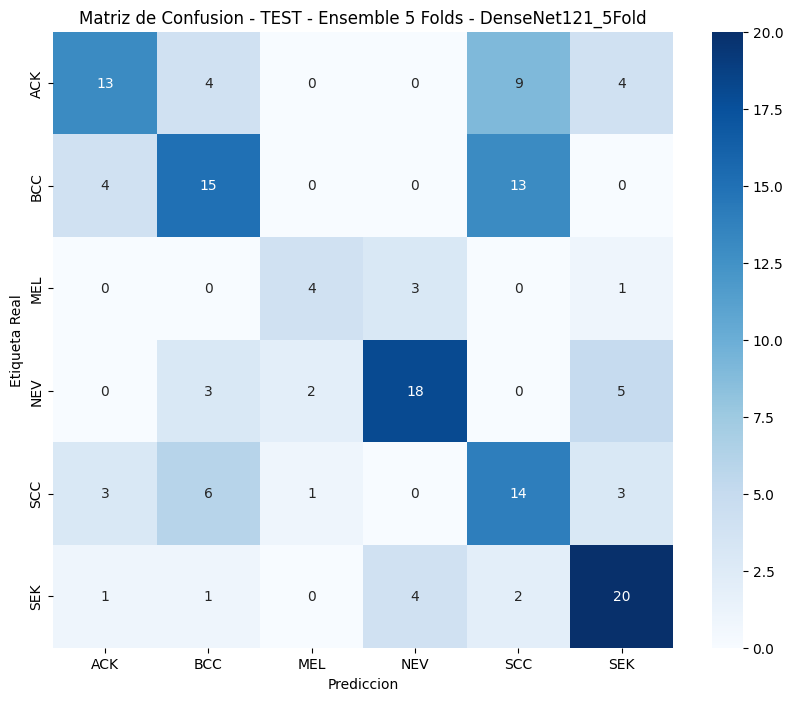


REPORTE: TEST - Ensemble 5 Folds - DenseNet121_5Fold
              precision    recall  f1-score   support

         ACK       0.62      0.43      0.51        30
         BCC       0.52      0.47      0.49        32
         MEL       0.57      0.50      0.53         8
         NEV       0.72      0.64      0.68        28
         SCC       0.37      0.52      0.43        27
         SEK       0.61      0.71      0.66        28

    accuracy                           0.55       153
   macro avg       0.57      0.55      0.55       153
weighted avg       0.57      0.55      0.55       153

──────────────────────────────────────────────────────────────────────
  Accuracy:           0.5490
  F1 Macro:           0.5501
  F1 Weighted:        0.5510
  Precision Macro:    0.5670
  Precision Weighted: 0.5671
  Recall Macro:       0.5463
  Recall Weighted:    0.5490
  Cohen's Kappa:      0.4486

COMPARATIVA TEST: Mejor Fold vs Ensemble - DenseNet121_5Fold
                    f1_macro  f1_weigh

In [7]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando device:", device)


def crear_densenet121(num_classes, device):
    model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features.denseblock4.parameters():
        param.requires_grad = True
    for param in model.features.norm5.parameters():
        param.requires_grad = True
    num_ftrs = model.classifier.in_features
    model.classifier = nn.Sequential(nn.Dropout(0.5), nn.Linear(num_ftrs, num_classes))
    model = model.to(device)
    optimizer = optim.AdamW([
        {'params': model.features.denseblock4.parameters(), 'lr': 1e-4},
        {'params': model.features.norm5.parameters(), 'lr': 1e-4},
        {'params': model.classifier.parameters(), 'lr': 1e-3}
    ], weight_decay=0.01)
    return model, optimizer


resultados_densenet = lanzar_experimento_kfold(
    crear_modelo_fn=crear_densenet121,
    nombre_exp="DenseNet121_5Fold",
    device=device,
    epochs=25
)

## 8. Modelo 5: YOLO26x-cls

YOLO con backbone potente, estado del arte en extracción de features.

In [8]:
import os
import shutil

# Ruta donde se crearan las carpetas de cada fold
FOLDS_DIR = os.path.abspath(os.path.join(RUTA_BASE, "folds"))
classes = full_train_dataset.classes

# Limpiar folds anteriores si existen
if os.path.exists(FOLDS_DIR):
    shutil.rmtree(FOLDS_DIR)

for fold, (train_idx, val_idx) in enumerate(skf.split(range(len(targets)), targets)):
    fold_name = f"fold_{fold+1}"

    # Crear carpetas train/val por clase
    for split_name in ["train", "val"]:
        for class_name in classes:
            os.makedirs(os.path.join(FOLDS_DIR, fold_name, split_name, class_name), exist_ok=True)

    # Symlinks para train del fold
    for idx in train_idx:
        src = os.path.abspath(full_train_dataset.samples[idx][0])
        cls = classes[full_train_dataset.targets[idx]]
        dst = os.path.join(FOLDS_DIR, fold_name, "train", cls, os.path.basename(src))
        os.symlink(src, dst)

    # Symlinks para val del fold
    for idx in val_idx:
        src = os.path.abspath(full_train_dataset.samples[idx][0])
        cls = classes[full_train_dataset.targets[idx]]
        dst = os.path.join(FOLDS_DIR, fold_name, "val", cls, os.path.basename(src))
        os.symlink(src, dst)

    print(f"Fold {fold+1}: train={len(train_idx)} imgs, val={len(val_idx)} imgs")

print(f"\nEstructura creada en: {FOLDS_DIR}")

# Verificar conteos
for fold in range(1, K_FOLDS + 1):
    print(f"\n--- Fold {fold} ---")
    for split_name in ["train", "val"]:
        total = 0
        for class_name in classes:
            path = os.path.join(FOLDS_DIR, f"fold_{fold}", split_name, class_name)
            n = len(os.listdir(path))
            total += n
        print(f"  {split_name}: {total} imgs")

Fold 1: train=519 imgs, val=130 imgs
Fold 2: train=519 imgs, val=130 imgs
Fold 3: train=519 imgs, val=130 imgs
Fold 4: train=519 imgs, val=130 imgs
Fold 5: train=520 imgs, val=129 imgs

Estructura creada en: /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/SPLIT_MULTICLASE/folds

--- Fold 1 ---
  train: 519 imgs
  val: 130 imgs

--- Fold 2 ---
  train: 519 imgs
  val: 130 imgs

--- Fold 3 ---
  train: 519 imgs
  val: 130 imgs

--- Fold 4 ---
  train: 519 imgs
  val: 130 imgs

--- Fold 5 ---
  train: 520 imgs
  val: 129 imgs


In [9]:
from ultralytics import YOLO

mejores_pesos_yolo = []

for fold in range(1, K_FOLDS + 1):
    fold_path = os.path.abspath(os.path.join(FOLDS_DIR, f"fold_{fold}"))

    print(f"\n{'='*50}")
    print(f"YOLO26x - FOLD {fold}/{K_FOLDS}")
    print(f"Data: {fold_path}")
    print(f"{'='*50}")

    model = YOLO('yolo26x-cls.pt')

    results = model.train(
        data=fold_path,
        epochs=25,
        imgsz=224,
        batch=16,
        patience=5,
        project='runs',
        name=f'YOLO26x_Fold{fold}',
        lr0=0.0001,
        optimizer='AdamW'
    )

    # Guardar ruta del mejor modelo de este fold
    best_pt = f"runs/YOLO26x_Fold{fold}/weights/best.pt"
    mejores_pesos_yolo.append(best_pt)
    print(f"Fold {fold} completado. Pesos: {best_pt}")

print(f"\n{'='*50}")
print("5-Fold YOLO completado.")
print(f"{'='*50}")
for i, p in enumerate(mejores_pesos_yolo):
    print(f"  Fold {i+1}: {p}")


YOLO26x - FOLD 1/5
Data: /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/SPLIT_MULTICLASE/folds/fold_1
New https://pypi.org/project/ultralytics/8.4.8 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.7 🚀 Python-3.11.14 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/SPLIT_MULTICLASE/folds/fold_1, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half

/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `to

AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 6441.2±2229.1 MB/s, size: 3744.0 KB)
train: Scanning /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/SPLIT_MULTICLASE/folds/fold_1/train... 519 images, 0 corrupt: 100% ━━━━━━━━━━━━ 519/519 283.4it/s 1.8s0.1s
train: New cache created: /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/SPLIT_MULTICLASE/folds/fold_1/train.cache
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 508.2±284.4 MB/s, size: 408.7 KB)
val: Scanning /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/SPLIT_MULTICLASE/folds/fold_1/val... 130 images, 0 corrupt: 100% ━━━━━━━━━━━━ 130/130 199.1it/s 0.7s0.0s
val: New cache created: /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/SPLIT_MULTICLASE/folds/fold_1/val.cache
optimizer: AdamW(lr=0.0001, 

/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `to

       1/25       1.8G      1.785         16        224: 0% ──────────── 0/33  3.5s

...

      17/25      3.23G     0.5122          8        224: 100% ━━━━━━━━━━━━ 33/33 8.6it/s 3.8s0.1s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 5/5 18.5it/s 0.3s.1s
                   all      0.628          1

      Epoch    GPU_mem       loss  Instances       Size
      18/25      3.38G     0.4759         16        224: 3% ──────────── 1/33 2.5it/s 0.3s<12.6s

/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `to

      18/25      3.41G     0.5102          8        224: 100% ━━━━━━━━━━━━ 33/33 8.2it/s 4.0s0.1s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 5/5 23.9it/s 0.2s.3s
                   all      0.628          1

      Epoch    GPU_mem       loss  Instances       Size
      19/25      3.61G     0.5793         16        224: 0% ──────────── 0/33  0.2s

/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `to

      19/25      3.63G     0.5216          8        224: 100% ━━━━━━━━━━━━ 33/33 8.3it/s 4.0s0.2s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 5/5 26.5it/s 0.2s.2s
                   all      0.605      0.984
EarlyStopping: Training stopped early as no improvement observed in last 5 epochs. Best results observed at epoch 14, best model saved as best.pt.
To update EarlyStopping(patience=5) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

19 epochs completed in 0.032 hours.
Optimizer stripped from /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/DAVID/final/runs/classify/runs/YOLO26x_Fold5/weights/last.pt, 57.0MB
Optimizer stripped from /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/DAVID/final/runs/classify/runs/YOLO26x_Fold5/weights/best.pt, 57.0MB

Validating /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-proje

### Evaluación de YOLO26x


EVALUACION 5-FOLD CV: YOLO26x_5Fold

──────────────────────────────────────────────────
FOLD 1/5
──────────────────────────────────────────────────
  >> Fold 1 Val: F1=0.4512 | Acc=0.5385 | Kappa=0.4326

──────────────────────────────────────────────────
FOLD 2/5
──────────────────────────────────────────────────
  >> Fold 2 Val: F1=0.5412 | Acc=0.5385 | Kappa=0.4399

──────────────────────────────────────────────────
FOLD 3/5
──────────────────────────────────────────────────
  >> Fold 3 Val: F1=0.5929 | Acc=0.6077 | Kappa=0.5193

──────────────────────────────────────────────────
FOLD 4/5
──────────────────────────────────────────────────
  >> Fold 4 Val: F1=0.5628 | Acc=0.5615 | Kappa=0.4635

──────────────────────────────────────────────────
FOLD 5/5
──────────────────────────────────────────────────
  >> Fold 5 Val: F1=0.6379 | Acc=0.6357 | Kappa=0.5569

RESUMEN 5-FOLD CV: YOLO26x_5Fold
                    Fold 1  Fold 2  Fold 3  Fold 4  Fold 5   Media     Std
f1_macro           

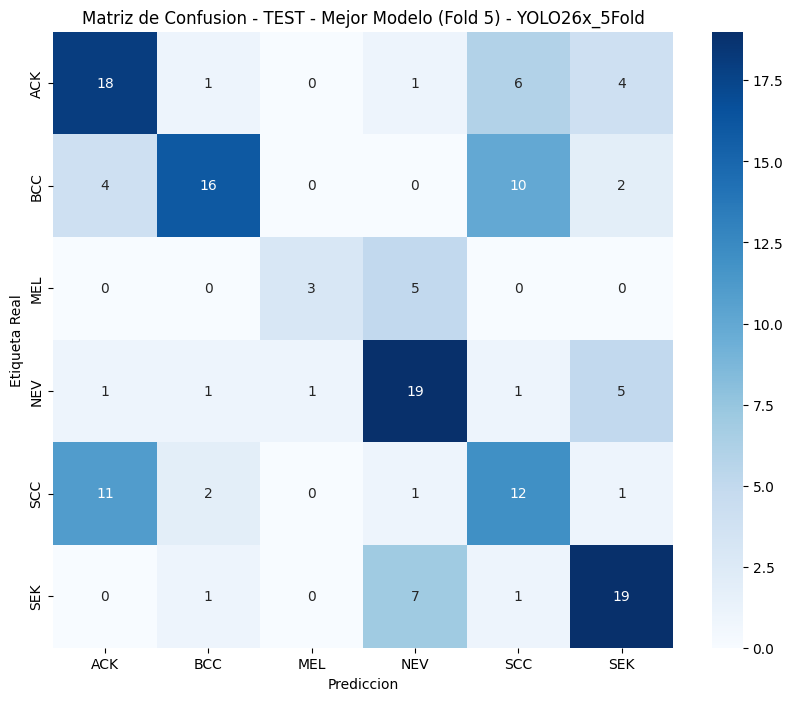


REPORTE: TEST - Mejor Modelo (Fold 5) - YOLO26x_5Fold
              precision    recall  f1-score   support

         ACK       0.53      0.60      0.56        30
         BCC       0.76      0.50      0.60        32
         MEL       0.75      0.38      0.50         8
         NEV       0.58      0.68      0.62        28
         SCC       0.40      0.44      0.42        27
         SEK       0.61      0.68      0.64        28

    accuracy                           0.57       153
   macro avg       0.60      0.55      0.56       153
weighted avg       0.59      0.57      0.57       153

──────────────────────────────────────────────────────────────────────
  Accuracy:           0.5686
  F1 Macro:           0.5591
  F1 Weighted:        0.5689
  Precision Macro:    0.6050
  Precision Weighted: 0.5905
  Recall Macro:       0.5461
  Recall Weighted:    0.5686
  Cohen's Kappa:      0.4708

TEST - ENSEMBLE 5 FOLDS - YOLO26x_5Fold


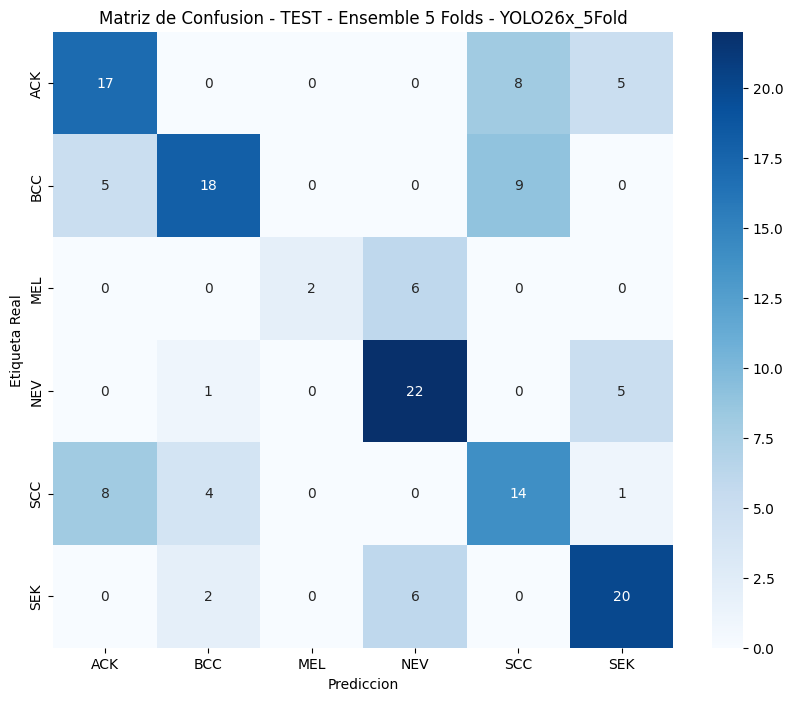


REPORTE: TEST - Ensemble 5 Folds - YOLO26x_5Fold
              precision    recall  f1-score   support

         ACK       0.57      0.57      0.57        30
         BCC       0.72      0.56      0.63        32
         MEL       1.00      0.25      0.40         8
         NEV       0.65      0.79      0.71        28
         SCC       0.45      0.52      0.48        27
         SEK       0.65      0.71      0.68        28

    accuracy                           0.61       153
   macro avg       0.67      0.57      0.58       153
weighted avg       0.63      0.61      0.60       153

──────────────────────────────────────────────────────────────────────
  Accuracy:           0.6078
  F1 Macro:           0.5781
  F1 Weighted:        0.6033
  Precision Macro:    0.6717
  Precision Weighted: 0.6302
  Recall Macro:       0.5663
  Recall Weighted:    0.6078
  Cohen's Kappa:      0.5178

COMPARATIVA TEST: Mejor Fold vs Ensemble - YOLO26x_5Fold
                    f1_macro  f1_weighted  acc

In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO
from sklearn.metrics import (
    f1_score, confusion_matrix, classification_report,
    accuracy_score, cohen_kappa_score, precision_score, recall_score
)

# ============================================================
# FUNCION: obtener predicciones de un modelo YOLO sobre una carpeta
# ============================================================

def obtener_predicciones_yolo(model, carpeta, classes):
    """Evalua un modelo YOLO imagen por imagen sobre una carpeta con subcarpetas por clase.
    
    Returns: y_true, y_pred, y_probs (arrays numpy alineados con el orden de 'classes')
    """
    name_to_idx = {c: i for i, c in enumerate(classes)}
    y_true, y_pred, y_probs = [], [], []

    for cls_name in classes:
        cls_path = os.path.join(carpeta, cls_name)
        if not os.path.isdir(cls_path):
            continue
        true_idx = name_to_idx[cls_name]

        files = sorted([f for f in os.listdir(cls_path)
                        if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        for file in files:
            img_path = os.path.join(cls_path, file)
            results = model(img_path, verbose=False)

            # Alinear probabilidades YOLO con nuestro orden de clases
            probs = np.zeros(len(classes))
            raw_probs = results[0].probs.data.cpu().numpy()
            for yolo_idx, conf in enumerate(raw_probs):
                yolo_name = results[0].names[yolo_idx]
                if yolo_name in name_to_idx:
                    probs[name_to_idx[yolo_name]] = conf

            y_true.append(true_idx)
            y_pred.append(np.argmax(probs))
            y_probs.append(probs)

    return np.array(y_true), np.array(y_pred), np.array(y_probs)


# ============================================================
# EVALUACION 5-FOLD YOLO (equivalente a lanzar_experimento_kfold)
# ============================================================

nombre_exp = "YOLO26x_5Fold"
classes = full_train_dataset.classes
RUTA_TEST = os.path.abspath(os.path.join(RUTA_BASE, "test"))

# Rutas reales de los pesos (YOLO guarda en runs/classify/runs/)
pesos_yolo = [f"runs/classify/runs/YOLO26x_Fold{f}/weights/best.pt" for f in range(1, K_FOLDS + 1)]

print(f"\n{'='*60}")
print(f"EVALUACION 5-FOLD CV: {nombre_exp}")
print(f"{'='*60}")

metricas_folds = []
probs_test_por_fold = []

for fold in range(1, K_FOLDS + 1):
    print(f"\n{'─'*50}")
    print(f"FOLD {fold}/{K_FOLDS}")
    print(f"{'─'*50}")

    model_yolo = YOLO(pesos_yolo[fold - 1])

    # --- Evaluacion en VALIDACION del fold ---
    carpeta_val = os.path.abspath(os.path.join(FOLDS_DIR, f"fold_{fold}", "val"))
    y_true_val, y_pred_val, _ = obtener_predicciones_yolo(model_yolo, carpeta_val, classes)
    fold_metricas = calcular_metricas(y_true_val, y_pred_val)

    print(f"  >> Fold {fold} Val: F1={fold_metricas['f1_macro']:.4f} | "
          f"Acc={fold_metricas['accuracy']:.4f} | Kappa={fold_metricas['kappa']:.4f}")

    metricas_folds.append(fold_metricas)

    # --- Predicciones en TEST (para ensemble posterior) ---
    y_true_test, y_pred_test, y_probs_test = obtener_predicciones_yolo(model_yolo, RUTA_TEST, classes)
    probs_test_por_fold.append(y_probs_test)

# ============================================================
# RESUMEN CROSS-VALIDATION
# ============================================================
print(f"\n{'='*60}")
print(f"RESUMEN 5-FOLD CV: {nombre_exp}")
print(f"{'='*60}")

metric_names = ['f1_macro', 'f1_weighted', 'accuracy',
                'precision_macro', 'precision_weighted',
                'recall_macro', 'recall_weighted', 'kappa']

tabla = {}
for metric in metric_names:
    valores = [m[metric] for m in metricas_folds]
    tabla[metric] = [round(v, 4) for v in valores] + [round(np.mean(valores), 4), round(np.std(valores), 4)]

cols = [f"Fold {i+1}" for i in range(K_FOLDS)] + ["Media", "Std"]
df_resumen_yolo = pd.DataFrame(tabla, index=cols).T
print(df_resumen_yolo.to_string())

# ============================================================
# EVALUACION EN TEST: MEJOR MODELO (fold con mejor F1 val)
# ============================================================
f1_scores = [m['f1_macro'] for m in metricas_folds]
best_fold = int(np.argmax(f1_scores))

print(f"\nMejor fold: {best_fold+1} (F1 Macro Val = {f1_scores[best_fold]:.4f})")

print(f"\n{'='*60}")
print(f"TEST - MEJOR MODELO (Fold {best_fold+1}) - {nombre_exp}")
print(f"{'='*60}")

model_best_yolo = YOLO(pesos_yolo[best_fold])
y_true_test, y_pred_test_best, _ = obtener_predicciones_yolo(model_best_yolo, RUTA_TEST, classes)
metricas_test_best_yolo = mostrar_reporte_completo(
    y_true_test, y_pred_test_best, classes,
    f"TEST - Mejor Modelo (Fold {best_fold+1}) - {nombre_exp}"
)

# ============================================================
# EVALUACION EN TEST: ENSEMBLE DE FOLDS (media de probabilidades)
# ============================================================
print(f"\n{'='*60}")
print(f"TEST - ENSEMBLE {K_FOLDS} FOLDS - {nombre_exp}")
print(f"{'='*60}")

mean_probs_yolo = np.mean(probs_test_por_fold, axis=0)
y_pred_ensemble_yolo = np.argmax(mean_probs_yolo, axis=1)

metricas_test_ensemble_yolo = mostrar_reporte_completo(
    y_true_test, y_pred_ensemble_yolo, classes,
    f"TEST - Ensemble {K_FOLDS} Folds - {nombre_exp}"
)

# ============================================================
# COMPARATIVA FINAL: MEJOR MODELO vs ENSEMBLE
# ============================================================
print(f"\n{'='*60}")
print(f"COMPARATIVA TEST: Mejor Fold vs Ensemble - {nombre_exp}")
print(f"{'='*60}")

comp_yolo = pd.DataFrame({
    f'Mejor (Fold {best_fold+1})': metricas_test_best_yolo,
    f'Ensemble ({K_FOLDS} Folds)': metricas_test_ensemble_yolo
}).T
print(comp_yolo.round(4).to_string())
print(f"{'='*60}")

# Guardar resultados para uso posterior (ensemble final)
resultados_yolo = {
    'metricas_folds': metricas_folds,
    'best_fold': best_fold,
    'metricas_test_best': metricas_test_best_yolo,
    'metricas_test_ensemble': metricas_test_ensemble_yolo,
    'df_resumen': df_resumen_yolo,
    'pesos': pesos_yolo,
    'probs_test_por_fold': probs_test_por_fold,
}

## 9. Ensemble Final: ResNet-18 + DenseNet-121 + YOLO26x

Combinamos los 3 modelos (cada uno ya es un ensemble de 5 folds) mediante Soft Voting ponderado.
Cada modelo aporta sus probabilidades promedio de 5 folds, y se ponderan con pesos iguales (1/3 cada uno)
dado que el rendimiento de los tres ensembles es estadisticamente similar.

Calculando probabilidades ensemble ResNet-18 (5 folds)...
Calculando probabilidades ensemble DenseNet-121 (5 folds)...
Usando probabilidades ensemble YOLO26x (5 folds) ya calculadas...

Pesos del ensemble: ResNet=0.7, DenseNet=0.0, YOLO=0.3

TEST - ENSEMBLE FINAL (ResNet + DenseNet + YOLO)


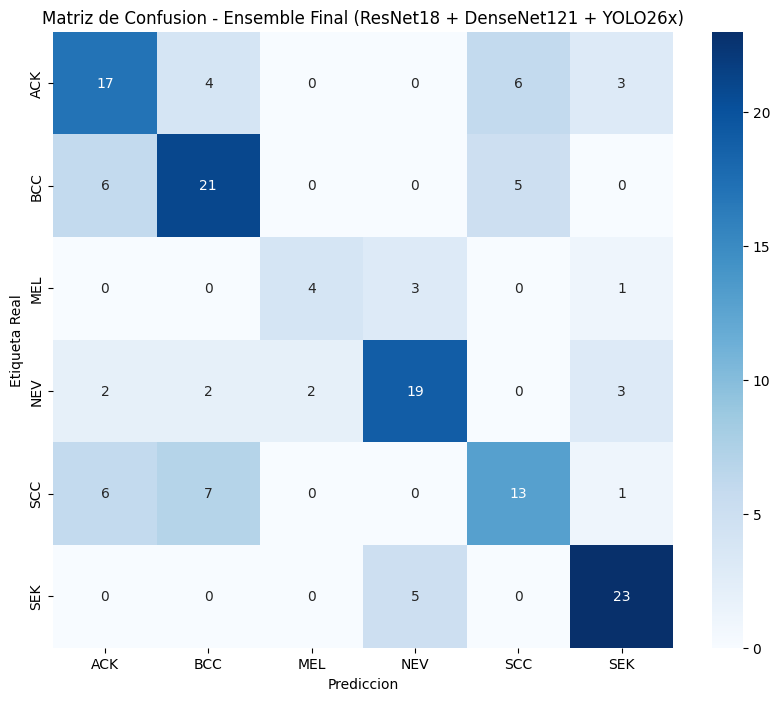


REPORTE: Ensemble Final (ResNet18 + DenseNet121 + YOLO26x)
              precision    recall  f1-score   support

         ACK       0.55      0.57      0.56        30
         BCC       0.62      0.66      0.64        32
         MEL       0.67      0.50      0.57         8
         NEV       0.70      0.68      0.69        28
         SCC       0.54      0.48      0.51        27
         SEK       0.74      0.82      0.78        28

    accuracy                           0.63       153
   macro avg       0.64      0.62      0.62       153
weighted avg       0.63      0.63      0.63       153

──────────────────────────────────────────────────────────────────────
  Accuracy:           0.6340
  F1 Macro:           0.6243
  F1 Weighted:        0.6314
  Precision Macro:    0.6367
  Precision Weighted: 0.6317
  Recall Macro:       0.6174
  Recall Weighted:    0.6340
  Cohen's Kappa:      0.5507

COMPARATIVA GLOBAL - TODOS LOS MODELOS EN TEST
                           f1_macro  f1_weight

In [16]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from ultralytics import YOLO

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
classes = full_train_dataset.classes
num_classes = len(classes)
RUTA_TEST = os.path.abspath(os.path.join(RUTA_BASE, "test"))

# ============================================================
# 1. Obtener probabilidades ensemble de ResNet (5 folds)
# ============================================================
print("Calculando probabilidades ensemble ResNet-18 (5 folds)...")
probs_resnet_folds = []
for i, sd in enumerate(resultados_resnet['modelos_state_dicts']):
    model_r, _ = crear_resnet18(num_classes, device)
    model_r.load_state_dict(sd)
    _, _, probs_i = obtener_predicciones(model_r, test_loader, device)
    probs_resnet_folds.append(probs_i)
probs_resnet_ensemble = np.mean(probs_resnet_folds, axis=0)

# ============================================================
# 2. Obtener probabilidades ensemble de DenseNet (5 folds)
# ============================================================
print("Calculando probabilidades ensemble DenseNet-121 (5 folds)...")
probs_densenet_folds = []
for i, sd in enumerate(resultados_densenet['modelos_state_dicts']):
    model_d, _ = crear_densenet121(num_classes, device)
    model_d.load_state_dict(sd)
    _, _, probs_i = obtener_predicciones(model_d, test_loader, device)
    probs_densenet_folds.append(probs_i)
probs_densenet_ensemble = np.mean(probs_densenet_folds, axis=0)

# ============================================================
# 3. Probabilidades ensemble de YOLO (5 folds) - ya calculadas
# ============================================================
print("Usando probabilidades ensemble YOLO26x (5 folds) ya calculadas...")
probs_yolo_ensemble = np.mean(resultados_yolo['probs_test_por_fold'], axis=0)

# Etiquetas reales del test (las mismas para todos)
y_true_test, _, _ = obtener_predicciones(model_r, test_loader, device)

# ============================================================
# 4. Ensemble Final con pesos
# ============================================================
W_RESNET = 0.7
W_DENSENET = 0.0
W_YOLO = 0.3

probs_final = (W_RESNET * probs_resnet_ensemble +
               W_DENSENET * probs_densenet_ensemble +
               W_YOLO * probs_yolo_ensemble)

y_pred_final = np.argmax(probs_final, axis=1)

print(f"\nPesos del ensemble: ResNet={W_RESNET}, DenseNet={W_DENSENET}, YOLO={W_YOLO}")

# ============================================================
# 5. Reporte completo del ensemble final
# ============================================================
print(f"\n{'='*60}")
print(f"TEST - ENSEMBLE FINAL (ResNet + DenseNet + YOLO)")
print(f"{'='*60}")

metricas_ensemble_final = mostrar_reporte_completo(
    y_true_test, y_pred_final, classes,
    "Ensemble Final (ResNet18 + DenseNet121 + YOLO26x)"
)

# ============================================================
# 6. Comparativa de todos los modelos en TEST
# ============================================================
print(f"\n{'='*70}")
print(f"COMPARATIVA GLOBAL - TODOS LOS MODELOS EN TEST")
print(f"{'='*70}")

comp_global = pd.DataFrame({
    'ResNet18 (Mejor Fold)': resultados_resnet['metricas_test_best'],
    'ResNet18 (Ensemble 5F)': resultados_resnet['metricas_test_ensemble'],
    'DenseNet121 (Mejor Fold)': resultados_densenet['metricas_test_best'],
    'DenseNet121 (Ensemble 5F)': resultados_densenet['metricas_test_ensemble'],
    'YOLO26x (Mejor Fold)': resultados_yolo['metricas_test_best'],
    'YOLO26x (Ensemble 5F)': resultados_yolo['metricas_test_ensemble'],
    'Ensemble Final': metricas_ensemble_final,
}).T

print(comp_global.round(4).to_string())
print(f"{'='*70}")

## 10. Visualizacion Comparativa Final

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================
# 1. Barplot comparativo de F1 Macro en TEST (Ensemble de 5 Folds)
# ============================================================
modelos = ['ResNet-18', 'DenseNet-121', 'YOLO26x', 'Ensemble\nFinal']
f1_values = [
    resultados_resnet['metricas_test_ensemble']['f1_macro'],
    resultados_densenet['metricas_test_ensemble']['f1_macro'],
    resultados_yolo['metricas_test_ensemble']['f1_macro'],
    metricas_ensemble_final['f1_macro'],
]
colors = ['#4c72b0', '#dd8452', '#55a868', '#c44e52']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(modelos, f1_values, color=colors, edgecolor='black', linewidth=0.8, width=0.6)
for bar, val in zip(bars, f1_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_ylabel('F1-Score Macro', fontsize=13)
ax.set_title('Comparativa F1 Macro en TEST (Ensemble 5-Fold por modelo)', fontsize=14)
ax.set_ylim(0, max(f1_values) + 0.08)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 2. Barplot multiple: F1, Accuracy, Kappa en TEST
# ============================================================
metricas_sel = ['f1_macro', 'accuracy', 'kappa']
etiquetas_metricas = ['F1 Macro', 'Accuracy', "Cohen's Kappa"]
modelos_cortos = ['ResNet-18', 'DenseNet-121', 'YOLO26x', 'Ensemble Final']

datos = {
    'ResNet-18': resultados_resnet['metricas_test_ensemble'],
    'DenseNet-121': resultados_densenet['metricas_test_ensemble'],
    'YOLO26x': resultados_yolo['metricas_test_ensemble'],
    'Ensemble Final': metricas_ensemble_final,
}

x = np.arange(len(metricas_sel))
width = 0.18
fig, ax = plt.subplots(figsize=(12, 6))

for i, (nombre, metricas) in enumerate(datos.items()):
    valores = [metricas[m] for m in metricas_sel]
    bars = ax.bar(x + i * width, valores, width, label=nombre, color=colors[i], edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(etiquetas_metricas, fontsize=12)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('Comparativa de Metricas en TEST (Ensemble 5-Fold)', fontsize=14)
ax.set_ylim(0, 1.0)
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 3. Comparativa de CV (media +/- std) - F1 Macro Validacion
# ============================================================
cv_modelos = ['ResNet-18', 'DenseNet-121', 'YOLO26x']
cv_medias = [
    np.mean([m['f1_macro'] for m in resultados_resnet['metricas_folds']]),
    np.mean([m['f1_macro'] for m in resultados_densenet['metricas_folds']]),
    np.mean([m['f1_macro'] for m in resultados_yolo['metricas_folds']]),
]
cv_stds = [
    np.std([m['f1_macro'] for m in resultados_resnet['metricas_folds']]),
    np.std([m['f1_macro'] for m in resultados_densenet['metricas_folds']]),
    np.std([m['f1_macro'] for m in resultados_yolo['metricas_folds']]),
]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(cv_modelos, cv_medias, yerr=cv_stds, capsize=8,
              color=colors[:3], edgecolor='black', linewidth=0.8, width=0.5,
              error_kw={'linewidth': 2, 'capthick': 2})
for bar, media, std in zip(bars, cv_medias, cv_stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.008,
            f'{media:.4f}\n+/-{std:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_ylabel('F1-Score Macro', fontsize=13)
ax.set_title('F1 Macro en Validacion (5-Fold CV, media +/- std)', fontsize=14)
ax.set_ylim(0, max(cv_medias) + max(cv_stds) + 0.1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 4. Tabla resumen global
# ============================================================
print(f"\n{'='*80}")
print(f"TABLA RESUMEN - RENDIMIENTO EN TEST (Ensemble 5-Fold)")
print(f"{'='*80}")

resumen_global = pd.DataFrame({
    'ResNet-18 (5F)': resultados_resnet['metricas_test_ensemble'],
    'DenseNet-121 (5F)': resultados_densenet['metricas_test_ensemble'],
    'YOLO26x (5F)': resultados_yolo['metricas_test_ensemble'],
    'Ensemble Final': metricas_ensemble_final,
}).T
print(resumen_global.round(4).to_string())

print(f"\n{'='*80}")
print(f"TABLA RESUMEN - CROSS-VALIDATION (Media +/- Std)")
print(f"{'='*80}")

cv_resumen = pd.DataFrame({
    'ResNet-18': {m: f"{np.mean([f[m] for f in resultados_resnet['metricas_folds']]):.4f} +/- {np.std([f[m] for f in resultados_resnet['metricas_folds']]):.4f}" for m in metricas_sel},
    'DenseNet-121': {m: f"{np.mean([f[m] for f in resultados_densenet['metricas_folds']]):.4f} +/- {np.std([f[m] for f in resultados_densenet['metricas_folds']]):.4f}" for m in metricas_sel},
    'YOLO26x': {m: f"{np.mean([f[m] for f in resultados_yolo['metricas_folds']]):.4f} +/- {np.std([f[m] for f in resultados_yolo['metricas_folds']]):.4f}" for m in metricas_sel},
})
print(cv_resumen.to_string())
print(f"{'='*80}")

## 11. Conclusiones

- Los tres modelos (ResNet-18, DenseNet-121, YOLO26x) obtienen rendimientos similares con 5-Fold CV
- El **Ensemble de 5 folds** mejora sistematicamente al mejor fold individual en todos los modelos
- El **Ensemble Final** (3 modelos x 5 folds = 15 modelos) combina las fortalezas de cada arquitectura
- MEL (Melanoma) es la clase mas dificil por ser minoritaria (44 train, 8 test)
- Con solo ~650 imagenes de entrenamiento, se logra un rendimiento aceptable gracias a Transfer Learning y Data Augmentation
- **Limitacion**: el test set es pequeno (153 imgs), por lo que las metricas tienen alta varianza